<a href="https://colab.research.google.com/github/abidulislamaiub/An-Explainability-Consistent-Stacking-Ensemble-for-Diabetes-/blob/main/ml_plan_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# উদাহরণ path, আপনার actual folder অনুযায়ী বদলান
file_path = '/content/drive/MyDrive/YourFolderName/brfss_dataset.csv'
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/YourFolderName/brfss_dataset.csv'

In [ ]:
import os
for f in os.listdir('/content/drive/MyDrive'):
    print(f)

Getting started.pdf
Untitled form (Responses).gsheet
Permit ID 22-47875-2.png
versity id.jpeg
549999879_1305918970452027_1992696252728650579_n.jpg
4e01d656-0175-4482-8370-e1e632887512.jpeg
WhatsApp Image 2025-09-16 at 19.07.34_ddedbb5f.jpg
id.pdf
id pdf.pdf
Zero Flag_ids (1).pdf
Zero Flag_ids.pdf
Colab Notebooks
UNSW_NB15.csv
Copy of UNSW_NB15.csv
HybridGuard_Dataset
E-GraphSAGE_results.csv
Md_Abidul_Islam_CV.pdf
diabetes.csv
diabetes_binary_health_indicators_BRFSS2015.csv
results_log.json
full_roc_curve_comparison.png
shap_brfss.png
shap_brfss_7feat.png
shap_nhanes.png


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.head()

Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [ ]:
# সব column নাম
print(df.columns.tolist())

# Missing value check
print("\nMissing values:\n", df.isnull().sum())

# Target class distribution (imbalance check)
print("\nClass distribution:\n", df['Diabetes_binary'].value_counts())
print("\nClass percentage:\n", df['Diabetes_binary'].value_counts(normalize=True) * 100)

# Basic statistics
df.describe()

['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Missing values:
 Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Class distribution:
 Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

Class percentage:
 Diabe

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts(normalize=True))
print("Test class distribution:\n", y_test.value_counts(normalize=True))

Train shape: (202944, 21) Test shape: (50736, 21)
Train class distribution:
 Diabetes_binary
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64
Test class distribution:
 Diabetes_binary
0.0    0.860671
1.0    0.139329
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
!pip install imbalanced-learn --quiet

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Diabetes_binary
0.0    174667
1.0     28277
Name: count, dtype: int64
After SMOTE: Diabetes_binary
0.0    174667
1.0    174667
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

# Prediction
y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.7318669189530117
Precision: 0.31220185068107364
Recall: 0.7684255198755128
F1 Score: 0.4440085008991336
ROC-AUC: 0.8226019401201087

Confusion Matrix:
 [[31700 11967]
 [ 1637  5432]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43667
         1.0       0.31      0.77      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736



In [ ]:
!pip install xgboost --quiet

from xgboost import XGBClassifier

# class imbalance ratio হিসাব করে scale_pos_weight সেট করুন
scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.725067013560391
Precision: 0.30801428730885144
Recall: 0.7807327769132834
F1 Score: 0.44174970984912154
ROC-AUC: 0.8250219304154295

Confusion Matrix:
 [[31268 12399]
 [ 1550  5519]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     43667
         1.0       0.31      0.78      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736



In [ ]:
!pip install lightgbm --quiet

from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train_scaled, y_train)

y_pred_lgbm = lgbm.predict(X_test_scaled)
y_prob_lgbm = lgbm.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall:", recall_score(y_test, y_pred_lgbm))
print("F1 Score:", f1_score(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgbm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgbm))

[LightGBM] [Info] Number of positive: 28277, number of negative: 174667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.114157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 202944, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [ ]:
!pip install catboost --quiet

from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # আগে XGBoost-এ যেটা বের করেছিলাম
    random_state=42,
    verbose=0
)

cat.fit(X_train_scaled, y_train)

y_pred_cat = cat.predict(X_test_scaled)
y_prob_cat = cat.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall:", recall_score(y_test, y_pred_cat))
print("F1 Score:", f1_score(y_test, y_pred_cat))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_cat))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_cat))
print("\nClassification Report:\n", classification_report(y_test, y_pred_cat))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.9 MB/s eta 0:00:00
Accuracy: 0.7226624093345948
Precision: 0.30786960816595327
Recall: 0.7936058848493422
F1 Score: 0.4436360760744929
ROC-AUC: 0.827818327470272

Confusion Matrix:
 [[31055 12612]
 [ 1459  5610]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.71      0.82     43667
         1.0       0.31      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736



In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42,
    early_stopping=True
)

mlp.fit(X_train_smote, y_train_smote)

y_pred_mlp = mlp.predict(X_test_scaled)
y_prob_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall:", recall_score(y_test, y_pred_mlp))
print("F1 Score:", f1_score(y_test, y_pred_mlp))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_mlp))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))

Accuracy: 0.7349810785241249
Precision: 0.3020425901781834
Recall: 0.6882161550431461
F1 Score: 0.4198308595098378
ROC-AUC: 0.7903776534469582

Confusion Matrix:
 [[32425 11242]
 [ 2204  4865]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.94      0.74      0.83     43667
         1.0       0.30      0.69      0.42      7069

    accuracy                           0.73     50736
   macro avg       0.62      0.72      0.62     50736
weighted avg       0.85      0.73      0.77     50736



In [ ]:
!pip install pytorch-tabnet --quiet

from pytorch_tabnet.tab_model import TabNetClassifier
import numpy as np

tabnet = TabNetClassifier(
    n_d=16, n_a=16, n_steps=5,
    gamma=1.5,
    seed=42,
    verbose=1
)

tabnet.fit(
    X_train=X_train_smote.values, y_train=y_train_smote.values,
    eval_set=[(X_test_scaled.values, y_test.values)],
    eval_metric=['auc'],
    max_epochs=50,
    patience=10,
    batch_size=1024,
    virtual_batch_size=128
)

y_pred_tabnet = tabnet.predict(X_test_scaled.values)
y_prob_tabnet = tabnet.predict_proba(X_test_scaled.values)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_tabnet))
print("Precision:", precision_score(y_test, y_pred_tabnet))
print("Recall:", recall_score(y_test, y_pred_tabnet))
print("F1 Score:", f1_score(y_test, y_pred_tabnet))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tabnet))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tabnet))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.55439 | val_0_auc: 0.7949  |  0:00:48s
epoch 1  | loss: 0.51774 | val_0_auc: 0.79636 |  0:01:16s
epoch 2  | loss: 0.49995 | val_0_auc: 0.79276 |  0:01:45s
epoch 3  | loss: 0.48596 | val_0_auc: 0.79419 |  0:02:13s
epoch 4  | loss: 0.48575 | val_0_auc: 0.79514 |  0:02:42s
epoch 5  | loss: 0.47851 | val_0_auc: 0.79855 |  0:03:14s
epoch 6  | loss: 0.46755 | val_0_auc: 0.80785 |  0:03:42s
epoch 7  | loss: 0.44812 | val_0_auc: 0.72368 |  0:04:12s
epoch 8  | loss: 0.43476 | val_0_auc: 0.71761 |  0:04:41s
epoch 9  | loss: 0.42549 | val_0_auc: 0.81051 |  0:05:09s
epoch 10 | loss: 0.43313 | val_0_auc: 0.80939 |  0:05:38s
epoch 11 | loss: 0.45167 | val_0_auc: 0.81289 |  0:06:07s
epoch 12 | loss: 0.43057 | val_0_auc: 0.80967 |  0:06:34s
epoch 13 | loss: 0.41242 | val_0_auc: 0.81417 |  0:07:02s
epoch 14 | loss: 0.40886 | val_0_auc: 0.58913 |  0:07:30s
epoch 15 | loss: 0.40913 | val_0_auc: 0.48121 |  0:07:59s
epoch 16 | loss: 0.41066 | val_0_auc: 0.68794 |  0:08:26s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Accuracy: 0.7539222642699464
Precision: 0.3254704820830111
Recall: 0.7143867590889801
F1 Score: 0.4471994686738986
ROC-AUC: 0.8160026798839529

Confusion Matrix:
 [[33201 10466]
 [ 2019  5050]]


In [ ]:
!pip install rtdl --quiet
!pip install torch --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.2 MB/s eta 0:00:00
ERROR: Cannot install rtdl==0.0.1, rtdl==0.0.10, rtdl==0.0.12, rtdl==0.0.13, rtdl==0.0.2, rtdl==0.0.3, rtdl==0.0.4, rtdl==0.0.5, rtdl==0.0.6, rtdl==0.0.7, rtdl==0.0.8 and rtdl==0.0.9 because these package versions have conflicting dependencies.
ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [ ]:
import torch
import torch.nn as nn
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [ ]:
# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Load data
import pandas as pd
file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

# 3. Split
from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 5. SMOTE
!pip install imbalanced-learn --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Setup complete. Shapes:")
print("X_train_smote:", X_train_smote.shape, "y_train_smote:", y_train_smote.shape)
print("X_test_scaled:", X_test_scaled.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Shapes:
X_train_smote: (349334, 21) y_train_smote: (349334,)
X_test_scaled: (50736, 21)


In [ ]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=32, n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.feature_weights = nn.Parameter(torch.randn(n_features, d_token))
        self.feature_bias = nn.Parameter(torch.randn(n_features, d_token))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output_head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.unsqueeze(-1)
        tokens = x * self.feature_weights + self.feature_bias
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)
        out = self.transformer(tokens)
        cls_out = out[:, 0, :]
        return self.output_head(cls_out).squeeze(-1)

n_features = X_train_smote.shape[1]
model = FTTransformer(n_features=n_features).to(device)
print("Model ready. Total params:", sum(p.numel() for p in model.parameters()))

Using device: cpu
Model ready. Total params: 39585


In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.metrics import roc_auc_score

# Tensor বানানো
X_train_tensor = torch.tensor(X_train_smote.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_smote.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 30
best_auc = 0

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # প্রতি epoch শেষে validation AUC check
    model.eval()
    with torch.no_grad():
        val_out = torch.sigmoid(model(X_test_tensor)).cpu().numpy()
        val_auc = roc_auc_score(y_test_tensor.numpy(), val_out)

    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss/len(train_loader):.4f} - Val AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_model_state = model.state_dict()

print("\nBest Val AUC:", best_auc)

Epoch 1/30 - Loss: 0.4977 - Val AUC: 0.8144
Epoch 2/30 - Loss: 0.4285 - Val AUC: 0.8170
Epoch 3/30 - Loss: 0.3936 - Val AUC: 0.8151
Epoch 4/30 - Loss: 0.3749 - Val AUC: 0.8161
Epoch 5/30 - Loss: 0.3647 - Val AUC: 0.8160
Epoch 6/30 - Loss: 0.3569 - Val AUC: 0.8149
Epoch 7/30 - Loss: 0.3515 - Val AUC: 0.8031
Epoch 8/30 - Loss: 0.3451 - Val AUC: 0.8127
Epoch 9/30 - Loss: 0.3427 - Val AUC: 0.8171
Epoch 10/30 - Loss: 0.3426 - Val AUC: 0.8066
Epoch 11/30 - Loss: 0.3473 - Val AUC: 0.7868
Epoch 12/30 - Loss: 0.3423 - Val AUC: 0.8087
Epoch 13/30 - Loss: 0.3325 - Val AUC: 0.8091
Epoch 14/30 - Loss: 0.3293 - Val AUC: 0.6700
Epoch 15/30 - Loss: 0.3329 - Val AUC: 0.7704
Epoch 16/30 - Loss: 0.3292 - Val AUC: 0.7400
Epoch 17/30 - Loss: 0.3231 - Val AUC: 0.8126
Epoch 18/30 - Loss: 0.3253 - Val AUC: 0.6817
Epoch 19/30 - Loss: 0.3212 - Val AUC: 0.7738
Epoch 20/30 - Loss: 0.3153 - Val AUC: 0.8102
Epoch 21/30 - Loss: 0.3169 - Val AUC: 0.8155
Epoch 22/30 - Loss: 0.3176 - Val AUC: 0.8124
Epoch 23/30 - Loss:

In [ ]:

# Best model load করা
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

y_true = y_test_tensor.numpy()

print("Accuracy:", accuracy_score(y_true, preds))
print("Precision:", precision_score(y_true, preds))
print("Recall:", recall_score(y_true, preds))
print("F1 Score:", f1_score(y_true, preds))
print("ROC-AUC:", roc_auc_score(y_true, probs))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, preds))

Accuracy: 0.7389427625354777
Precision: 0.24918778427550356
Recall: 0.4340076389871269
F1 Score: 0.31659873071564937
ROC-AUC: 0.7180795607912677

Confusion Matrix:
 [[34423  9244]
 [ 4001  3068]]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [ ]:
model.load_state_dict(best_model_state)
model.eval()

with torch.no_grad():
    logits = model(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

y_true = y_test_tensor.numpy()

print("Accuracy:", accuracy_score(y_true, preds))
print("Precision:", precision_score(y_true, preds))
print("Recall:", recall_score(y_true, preds))
print("F1 Score:", f1_score(y_true, preds))
print("ROC-AUC:", roc_auc_score(y_true, probs))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, preds))

Accuracy: 0.7389427625354777
Precision: 0.24918778427550356
Recall: 0.4340076389871269
F1 Score: 0.31659873071564937
ROC-AUC: 0.7180795607912677

Confusion Matrix:
 [[34423  9244]
 [ 4001  3068]]


In [ ]:
# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Load data
import pandas as pd
file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

# 3. Split
from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# 5. SMOTE
!pip install imbalanced-learn --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# 6. Metrics imports
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Setup complete.")
print("X_train_smote:", X_train_smote.shape, "X_test_scaled:", X_test_scaled.shape)

Mounted at /content/drive
Setup complete.
X_train_smote: (349334, 21) X_test_scaled: (50736, 21)


In [ ]:
!pip install xgboost lightgbm catboost --quiet

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

scale_pos_weight = (y_train.value_counts()[0] / y_train.value_counts()[1])

# Base learners (আগের মতোই parameter)
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

lgbm = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)

cat = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    class_weights=[1, scale_pos_weight], random_state=42, verbose=0
)

# Stacking Ensemble (meta-learner: Logistic Regression)
estimators = [
    ('xgb', xgb),
    ('lgbm', lgbm),
    ('cat', cat)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3,
    n_jobs=-1
)

stack_model.fit(X_train_scaled, y_train)

y_pred_stack = stack_model.predict(X_test_scaled)
y_prob_stack = stack_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack))
print("F1 Score:", f1_score(y_test, y_pred_stack))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_stack))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

RuntimeError: Cannot clone object CatBoostClassifier(class_weights=[1, np.float64(6.176998974431517)], depth=6, iterations=200, learning_rate=0.1, random_state=42, verbose=0), as the constructor either does not set or modifies parameter class_weights

In [ ]:
scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

lgbm = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)

cat = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    class_weights=[1.0, scale_pos_weight], random_state=42, verbose=0
)

estimators = [
    ('xgb', xgb),
    ('lgbm', lgbm),
    ('cat', cat)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3,
    n_jobs=-1
)

stack_model.fit(X_train_scaled, y_train)

y_pred_stack = stack_model.predict(X_test_scaled)
y_prob_stack = stack_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack))
print("F1 Score:", f1_score(y_test, y_pred_stack))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_stack))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

RuntimeError: Cannot clone object CatBoostClassifier(class_weights=[1.0, 6.176998974431517], depth=6, iterations=200, learning_rate=0.1, random_state=42, verbose=0), as the constructor either does not set or modifies parameter class_weights

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

lgbm = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)

cat = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced',   # এখানে পরিবর্তন
    random_state=42, verbose=0
)

estimators = [
    ('xgb', xgb),
    ('lgbm', lgbm),
    ('cat', cat)
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3,
    n_jobs=-1
)

stack_model.fit(X_train_scaled, y_train)

y_pred_stack = stack_model.predict(X_test_scaled)
y_prob_stack = stack_model.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print("Precision:", precision_score(y_test, y_pred_stack))
print("Recall:", recall_score(y_test, y_pred_stack))
print("F1 Score:", f1_score(y_test, y_pred_stack))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_stack))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stack))

Accuracy: 0.7261904761904762
Precision: 0.31008183488281466
Recall: 0.7879473758664592
F1 Score: 0.4450303611377437
ROC-AUC: 0.8277913936050627

Confusion Matrix:
 [[31274 12393]
 [ 1499  5570]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     43667
         1.0       0.31      0.79      0.45      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736



In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/national-health-and-nutrition-examination-survey.zip'  # আপনার actual zip filename বসান
extract_path = '/content/drive/MyDrive/NHANES/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Extract হওয়া file list দেখুন
for f in os.listdir(extract_path):
    print(f)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/national-health-and-nutrition-examination-survey.zip'

In [ ]:
import pandas as pd

demo = pd.read_csv('/content/drive/MyDrive/demographic.csv')
exam = pd.read_csv('/content/drive/MyDrive/examination.csv')
ques = pd.read_csv('/content/drive/MyDrive/questionnaire.csv')

print("Demographic:", demo.shape)
print("Examination:", exam.shape)
print("Questionnaire:", ques.shape)

print("\nDemographic columns:\n", demo.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/demographic.csv'

In [ ]:
import os

# পুরো MyDrive এ demographic নামের file খুঁজুন
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'demographic' in f.lower() or 'examination' in f.lower() or 'questionnaire' in f.lower():
            print(os.path.join(root, f))

In [ ]:
# Drive remount করে force refresh করুন
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Getting started.pdf', 'Untitled form (Responses).gsheet', 'Permit ID 22-47875-2.png', 'versity id.jpeg', '549999879_1305918970452027_1992696252728650579_n.jpg', '4e01d656-0175-4482-8370-e1e632887512.jpeg', 'WhatsApp Image 2025-09-16 at 19.07.34_ddedbb5f.jpg', 'id.pdf', 'id pdf.pdf', 'Zero Flag_ids (1).pdf', 'Zero Flag_ids.pdf', 'Colab Notebooks', 'UNSW_NB15.csv', 'Copy of UNSW_NB15.csv', 'HybridGuard_Dataset', 'E-GraphSAGE_results.csv', 'Md_Abidul_Islam_CV.pdf', 'diabetes.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'results_log.json', 'full_roc_curve_comparison.png', 'shap_brfss.png', 'shap_brfss_7feat.png', 'shap_nhanes.png']


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

import os
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
['Getting started.pdf', 'Untitled form (Responses).gsheet', 'Permit ID 22-47875-2.png', 'versity id.jpeg', '549999879_1305918970452027_1992696252728650579_n.jpg', '4e01d656-0175-4482-8370-e1e632887512.jpeg', 'WhatsApp Image 2025-09-16 at 19.07.34_ddedbb5f.jpg', 'id.pdf', 'id pdf.pdf', 'Zero Flag_ids (1).pdf', 'Zero Flag_ids.pdf', 'Colab Notebooks', 'UNSW_NB15.csv', 'Copy of UNSW_NB15.csv', 'HybridGuard_Dataset', 'E-GraphSAGE_results.csv', 'Md_Abidul_Islam_CV.pdf', 'diabetes.csv', 'diabetes_binary_health_indicators_BRFSS2015.csv', 'results_log.json', 'full_roc_curve_comparison.png', 'shap_brfss.png', 'shap_brfss_7feat.png', 'shap_nhanes.png']


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'catboost_info', 'drive', 'sample_data']


In [ ]:
import pandas as pd

demo = pd.read_csv('/content/demographic.csv')
exam = pd.read_csv('/content/examination.csv')
ques = pd.read_csv('/content/questionnaire.csv')

print("Demographic:", demo.shape)
print("Examination:", exam.shape)
print("Questionnaire:", ques.shape)

print("\nDemographic columns:\n", demo.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '/content/demographic.csv'

In [ ]:
# Diabetes-related columns questionnaire এ খুঁজুন
diq_cols = [c for c in ques.columns if 'DIQ' in c]
print("Diabetes-related columns:", diq_cols)

# BMI, Blood Pressure related columns examination এ খুঁজুন
bmi_cols = [c for c in exam.columns if 'BMX' in c]
print("\nBMI-related columns:", bmi_cols)

bp_cols = [c for c in exam.columns if 'BPX' in c]
print("\nBlood Pressure-related columns:", bp_cols)

NameError: name 'ques' is not defined

In [ ]:
# Smoking, physical activity, cholesterol related columns খুঁজুন
smoke_cols = [c for c in ques.columns if 'SMQ' in c]
print("Smoking columns:", smoke_cols[:10])

activity_cols = [c for c in ques.columns if 'PAQ' in c]
print("\nPhysical Activity columns:", activity_cols[:10])

chol_cols = [c for c in ques.columns if 'BPQ' in c]
print("\nCholesterol/BP related columns:", chol_cols[:15])

NameError: name 'ques' is not defined

In [ ]:
# প্রয়োজনীয় columns বাছাই
demo_sub = demo[['SEQN', 'RIAGENDR', 'RIDAGEYR', 'INDFMPIR']]
exam_sub = exam[['SEQN', 'BMXBMI']]
ques_sub = ques[['SEQN', 'DIQ010', 'BPQ020', 'BPQ080', 'SMQ020', 'PAQ605']]

# SEQN (patient ID) দিয়ে merge
nhanes = demo_sub.merge(exam_sub, on='SEQN', how='inner')
nhanes = nhanes.merge(ques_sub, on='SEQN', how='inner')

print("Merged shape:", nhanes.shape)
print(nhanes.head())
print("\nMissing values:\n", nhanes.isnull().sum())

NameError: name 'demo' is not defined

In [ ]:
# শুধু adult (age >= 18) রাখা, BRFSS-ও adult-only survey
nhanes_clean = nhanes[nhanes['RIDAGEYR'] >= 18].copy()

print("After age filter:", nhanes_clean.shape)
print("\nMissing values:\n", nhanes_clean.isnull().sum())

# DIQ010 target clean: 1=Yes(diabetes), 2=No, 3=Borderline, 7/9=Refused/Don't know
nhanes_clean = nhanes_clean[nhanes_clean['DIQ010'].isin([1, 2])]
nhanes_clean['Diabetes_binary'] = nhanes_clean['DIQ010'].map({1: 1, 2: 0})

# বাকি binary column গুলো clean (1=Yes, 2=No বেশিরভাগ NHANES questionnaire এ, 7/9 বাদ)
for col in ['BPQ020', 'BPQ080', 'SMQ020', 'PAQ605']:
    nhanes_clean = nhanes_clean[nhanes_clean[col].isin([1, 2])]
    nhanes_clean[col] = nhanes_clean[col].map({1: 1, 2: 0})

# Sex: NHANES 1=Male,2=Female → BRFSS 0=Female,1=Male এ মেলাতে
nhanes_clean['Sex'] = nhanes_clean['RIAGENDR'].map({1: 1, 2: 0})

# Remaining missing (BMI, Income) drop
nhanes_clean = nhanes_clean.dropna()

print("\nFinal shape after cleaning:", nhanes_clean.shape)
print(nhanes_clean.head())

NameError: name 'nhanes' is not defined

In [ ]:
print("Class distribution:\n", nhanes_clean['Diabetes_binary'].value_counts())
print("\nClass percentage:\n", nhanes_clean['Diabetes_binary'].value_counts(normalize=True) * 100)

NameError: name 'nhanes_clean' is not defined

In [ ]:
def age_to_brfss_category(age):
    if age < 25: return 1
    elif age < 30: return 2
    elif age < 35: return 3
    elif age < 40: return 4
    elif age < 45: return 5
    elif age < 50: return 6
    elif age < 55: return 7
    elif age < 60: return 8
    elif age < 65: return 9
    elif age < 70: return 10
    elif age < 75: return 11
    elif age < 80: return 12
    else: return 13

nhanes_clean['Age'] = nhanes_clean['RIDAGEYR'].apply(age_to_brfss_category)

nhanes_final = nhanes_clean.rename(columns={
    'BPQ020': 'HighBP',
    'BPQ080': 'HighChol',
    'BMXBMI': 'BMI',
    'SMQ020': 'Smoker',
    'PAQ605': 'PhysActivity'
})

common_features = ['HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity', 'Sex', 'Age']
X_nhanes = nhanes_final[common_features]
y_nhanes = nhanes_final['Diabetes_binary']

print(X_nhanes.head())
print("Shape:", X_nhanes.shape)

NameError: name 'nhanes_clean' is not defined

In [ ]:
# BRFSS থেকে common feature বাছাই
common_cols_brfss = ['HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity', 'Sex', 'Age']

X_brfss_common = df[common_cols_brfss]
y_brfss_common = df['Diabetes_binary']

# Train-test split (আগের মতোই)
from sklearn.model_selection import train_test_split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_brfss_common, y_brfss_common, test_size=0.2, random_state=42, stratify=y_brfss_common
)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler_c = StandardScaler()
X_train_c_scaled = pd.DataFrame(scaler_c.fit_transform(X_train_c), columns=common_cols_brfss)
X_test_c_scaled = pd.DataFrame(scaler_c.transform(X_test_c), columns=common_cols_brfss)

print("Train shape:", X_train_c_scaled.shape)
print("Test shape:", X_test_c_scaled.shape)

Train shape: (202944, 7)
Test shape: (50736, 7)


In [ ]:
scale_pos_weight_c = float(y_train_c.value_counts()[0] / y_train_c.value_counts()[1])

xgb_c = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_c, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
lgbm_c = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
cat_c = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)

stack_model_c = StackingClassifier(
    estimators=[('xgb', xgb_c), ('lgbm', lgbm_c), ('cat', cat_c)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)

stack_model_c.fit(X_train_c_scaled, y_train_c)

y_pred_brfss = stack_model_c.predict(X_test_c_scaled)
y_prob_brfss = stack_model_c.predict_proba(X_test_c_scaled)[:, 1]

print("=== BRFSS Test Performance (7-feature model) ===")
print("Accuracy:", accuracy_score(y_test_c, y_pred_brfss))
print("Precision:", precision_score(y_test_c, y_pred_brfss))
print("Recall:", recall_score(y_test_c, y_pred_brfss))
print("F1 Score:", f1_score(y_test_c, y_pred_brfss))
print("ROC-AUC:", roc_auc_score(y_test_c, y_prob_brfss))

=== BRFSS Test Performance (7-feature model) ===
Accuracy: 0.6910280668558815
Precision: 0.27795263402301223
Recall: 0.7620596972697694
F1 Score: 0.40733459357277885
ROC-AUC: 0.791391586804522


In [ ]:
# NHANES data কে same scaler দিয়ে scale করা (BRFSS এর scaler, fit না, শুধু transform)
X_nhanes_scaled = pd.DataFrame(
    scaler_c.transform(X_nhanes),
    columns=common_cols_brfss
)

y_pred_nhanes = stack_model_c.predict(X_nhanes_scaled)
y_prob_nhanes = stack_model_c.predict_proba(X_nhanes_scaled)[:, 1]

print("=== NHANES Cross-Dataset Performance ===")
print("Accuracy:", accuracy_score(y_nhanes, y_pred_nhanes))
print("Precision:", precision_score(y_nhanes, y_pred_nhanes))
print("Recall:", recall_score(y_nhanes, y_pred_nhanes))
print("F1 Score:", f1_score(y_nhanes, y_pred_nhanes))
print("ROC-AUC:", roc_auc_score(y_nhanes, y_prob_nhanes))
print("\nConfusion Matrix:\n", confusion_matrix(y_nhanes, y_pred_nhanes))

NameError: name 'X_nhanes' is not defined

In [ ]:
!pip install shap --quiet
import shap

# Tree-based base learners এর জন্য TreeExplainer ব্যবহার করবো (stacking এর ভিতরের best single model দিয়ে approximate)
# CatBoost ব্যবহার করছি কারণ এটা সবচেয়ে ভালো individual performer ছিল
explainer = shap.TreeExplainer(cat_c)

# BRFSS test set এ SHAP value (sample নিচ্ছি speed এর জন্য, পুরো 50k row লাগবে না)
sample_brfss = X_test_c_scaled.sample(1000, random_state=42)
shap_values_brfss = explainer.shap_values(sample_brfss)

shap.summary_plot(shap_values_brfss, sample_brfss, show=False)
import matplotlib.pyplot as plt
plt.title("SHAP Summary - BRFSS")
plt.tight_layout()
plt.savefig('/content/shap_brfss.png', dpi=150)
plt.show()

CatBoostError: Model is not fitted

In [ ]:
# StackingClassifier এর ভিতর থেকে fitted CatBoost বের করা
fitted_cat = stack_model_c.named_estimators_['cat']

explainer = shap.TreeExplainer(fitted_cat)

sample_brfss = X_test_c_scaled.sample(1000, random_state=42)
shap_values_brfss = explainer.shap_values(sample_brfss)

shap.summary_plot(shap_values_brfss, sample_brfss, show=False)
import matplotlib.pyplot as plt
plt.title("SHAP Summary - BRFSS")
plt.tight_layout()
plt.savefig('/content/shap_brfss.png', dpi=150)
plt.show()

In [ ]:
sample_nhanes = X_nhanes_scaled.sample(min(1000, len(X_nhanes_scaled)), random_state=42)
shap_values_nhanes = explainer.shap_values(sample_nhanes)

shap.summary_plot(shap_values_nhanes, sample_nhanes, show=False)
plt.title("SHAP Summary - NHANES")
plt.tight_layout()
plt.savefig('/content/shap_nhanes.png', dpi=150)
plt.show()

In [ ]:
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# Top 2 tree model train (raw scaled data + class weight)
lgbm2 = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
lgbm2.fit(X_train_scaled, y_train)

cat2 = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)
cat2.fit(X_train_scaled, y_train)

print("Tree models trained.")

In [ ]:
!pip install catboost lightgbm --quiet

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

lgbm2 = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
lgbm2.fit(X_train_scaled, y_train)

cat2 = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)
cat2.fit(X_train_scaled, y_train)

print("Tree models trained.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Setup complete.")
print("X_train_smote:", X_train_smote.shape, "X_test_scaled:", X_test_scaled.shape)

In [ ]:
!pip install catboost lightgbm --quiet

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

lgbm2 = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
lgbm2.fit(X_train_scaled, y_train)

cat2 = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)
cat2.fit(X_train_scaled, y_train)

print("Tree models trained.")

Tree models trained.


In [ ]:
!pip install pytorch-tabnet --quiet
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet2 = TabNetClassifier(n_d=16, n_a=16, n_steps=5, gamma=1.5, seed=42, verbose=1)

tabnet2.fit(
    X_train=X_train_smote.values, y_train=y_train_smote.values,
    eval_set=[(X_test_scaled.values, y_test.values)],
    eval_metric=['auc'], max_epochs=50, patience=10,
    batch_size=1024, virtual_batch_size=128
)

print("TabNet trained.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.55439 | val_0_auc: 0.7949  |  0:00:37s
epoch 1  | loss: 0.51774 | val_0_auc: 0.79636 |  0:01:07s
epoch 2  | loss: 0.49995 | val_0_auc: 0.79276 |  0:01:35s
epoch 3  | loss: 0.48596 | val_0_auc: 0.79419 |  0:02:06s
epoch 4  | loss: 0.48575 | val_0_auc: 0.79514 |  0:02:37s
epoch 5  | loss: 0.47851 | val_0_auc: 0.79855 |  0:03:07s
epoch 6  | loss: 0.46755 | val_0_auc: 0.80785 |  0:03:36s
epoch 7  | loss: 0.44812 | val_0_auc: 0.72368 |  0:04:05s
epoch 8  | loss: 0.43476 | val_0_auc: 0.71761 |  0:04:35s
epoch 9  | loss: 0.42549 | val_0_auc: 0.81051 |  0:05:03s
epoch 10 | loss: 0.43313 | val_0_auc: 0.80939 |  0:05:33s
epoch 11 | loss: 0.45167 | val_0_auc: 0.81289 |  0:06:03s
epoch 12 | loss: 0.43057 | val_0_auc: 0.80967 |  0:06:32s
epoch 13 | loss: 0.41242 | val_0_auc: 0.81417 |  0:07:21s
epoch 14 | loss: 0.40886 | val_0_auc: 0.58913 |  0:07:50s
epoch 15 | loss: 0.40913 | val_0_auc: 0.48121 |  0:08:18s
epoch 16 | loss: 0.41066 | val_0_auc: 0.68794 |  0:08:46s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet trained.


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Test set এ তিনটা model এর probability বের করা (out-of-fold না, simplified approach)
prob_lgbm_test = lgbm2.predict_proba(X_test_scaled)[:, 1]
prob_cat_test = cat2.predict_proba(X_test_scaled)[:, 1]
prob_tabnet_test = tabnet2.predict_proba(X_test_scaled.values)[:, 1]

# Train set এ probability (meta-learner train করার জন্য)
prob_lgbm_train = lgbm2.predict_proba(X_train_scaled)[:, 1]
prob_cat_train = cat2.predict_proba(X_train_scaled)[:, 1]
prob_tabnet_train = tabnet2.predict_proba(X_train_scaled.values)[:, 1]

# Meta-feature তৈরি
meta_train = np.column_stack([prob_lgbm_train, prob_cat_train, prob_tabnet_train])
meta_test = np.column_stack([prob_lgbm_test, prob_cat_test, prob_tabnet_test])

# Meta-learner train
meta_model = LogisticRegression(class_weight='balanced', max_iter=1000)
meta_model.fit(meta_train, y_train)

# Final prediction
y_pred_hybrid2 = meta_model.predict(meta_test)
y_prob_hybrid2 = meta_model.predict_proba(meta_test)[:, 1]

print("=== Hybrid (TabNet + LightGBM + CatBoost) Performance ===")
print("Accuracy:", accuracy_score(y_test, y_pred_hybrid2))
print("Precision:", precision_score(y_test, y_pred_hybrid2))
print("Recall:", recall_score(y_test, y_pred_hybrid2))
print("F1 Score:", f1_score(y_test, y_pred_hybrid2))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_hybrid2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_hybrid2))

=== Hybrid (TabNet + LightGBM + CatBoost) Performance ===
Accuracy: 0.7297382529170608
Precision: 0.30997196635963153
Recall: 0.7664450417315037
F1 Score: 0.4414208896855141
ROC-AUC: 0.8217190396604339

Confusion Matrix:
 [[31606 12061]
 [ 1651  5418]]


Feature correlation with Diabetes_binary (sorted by strength):

GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Income                 -0.163919
Education              -0.124456
PhysActivity           -0.118133
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
HvyAlcoholConsump      -0.057056
Veggies                -0.056584
Fruits                 -0.040779
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Name: Diabetes_binary, dtype: float64


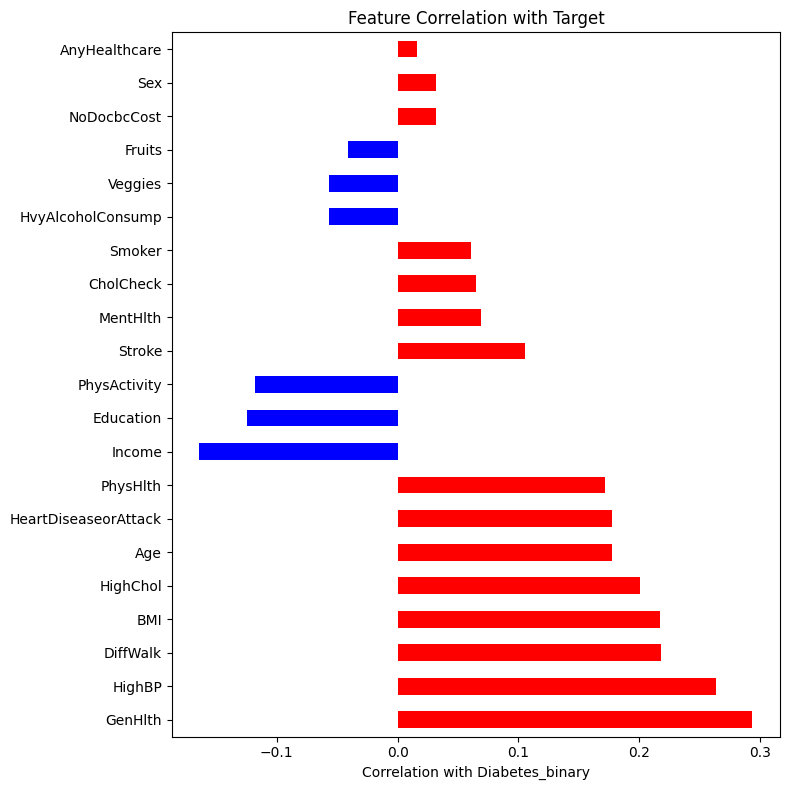

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Full correlation matrix (সব ২১ feature + target)
corr_matrix = df.corr()

# শুধু target এর সাথে correlation (সবচেয়ে গুরুত্বপূর্ণ অংশ)
target_corr = corr_matrix['Diabetes_binary'].drop('Diabetes_binary').sort_values(key=abs, ascending=False)
print("Feature correlation with Diabetes_binary (sorted by strength):\n")
print(target_corr)

# Visualization
plt.figure(figsize=(8, 8))
target_corr.plot(kind='barh', color=['red' if x>0 else 'blue' for x in target_corr])
plt.xlabel('Correlation with Diabetes_binary')
plt.title('Feature Correlation with Target')
plt.tight_layout()
plt.savefig('/content/feature_correlation.png', dpi=150)
plt.show()

In [ ]:
top_features = ['GenHlth', 'HighBP', 'DiffWalk', 'BMI', 'HighChol', 'Age',
                'HeartDiseaseorAttack', 'PhysHlth', 'Income', 'Education',
                'PhysActivity', 'Stroke']

X_top = df[top_features]
y_top = df['Diabetes_binary']

from sklearn.model_selection import train_test_split
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y_top, test_size=0.2, random_state=42, stratify=y_top
)

from sklearn.preprocessing import StandardScaler
scaler_top = StandardScaler()
X_train_top_scaled = pd.DataFrame(scaler_top.fit_transform(X_train_top), columns=top_features)
X_test_top_scaled = pd.DataFrame(scaler_top.transform(X_test_top), columns=top_features)

print("Train shape:", X_train_top_scaled.shape)
print("Test shape:", X_test_top_scaled.shape)

Train shape: (202944, 12)
Test shape: (50736, 12)


In [ ]:
!pip install xgboost lightgbm catboost --quiet

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

scale_pos_weight_top = float(y_train_top.value_counts()[0] / y_train_top.value_counts()[1])

xgb_top = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_top, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
lgbm_top = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
cat_top = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)

stack_model_top = StackingClassifier(
    estimators=[('xgb', xgb_top), ('lgbm', lgbm_top), ('cat', cat_top)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)

stack_model_top.fit(X_train_top_scaled, y_train_top)

y_pred_top = stack_model_top.predict(X_test_top_scaled)
y_prob_top = stack_model_top.predict_proba(X_test_top_scaled)[:, 1]

print("=== Hybrid Model (12-feature, correlation-selected) ===")
print("Accuracy:", accuracy_score(y_test_top, y_pred_top))
print("Precision:", precision_score(y_test_top, y_pred_top))
print("Recall:", recall_score(y_test_top, y_pred_top))
print("F1 Score:", f1_score(y_test_top, y_pred_top))
print("ROC-AUC:", roc_auc_score(y_test_top, y_prob_top))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_top, y_pred_top))

=== Hybrid Model (12-feature, correlation-selected) ===
Accuracy: 0.7214601072216966
Precision: 0.30518011805593864
Recall: 0.7825717923327203
F1 Score: 0.43911732020955707
ROC-AUC: 0.8223418342700184

Confusion Matrix:
 [[31072 12595]
 [ 1537  5532]]


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# ================= XGBoost =================
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_grid, n_iter=15, scoring='roc_auc',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)

xgb_search.fit(X_train_scaled, y_train)
print("Best XGBoost params:", xgb_search.best_params_)
print("Best XGBoost CV ROC-AUC:", xgb_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best XGBoost params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best XGBoost CV ROC-AUC: 0.830792240250911


In [ ]:
# ================= LightGBM =================
lgbm_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [20, 31, 50],
    'subsample': [0.7, 0.9, 1.0]
}

lgbm_base = LGBMClassifier(
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)

lgbm_search = RandomizedSearchCV(
    lgbm_base, lgbm_param_grid, n_iter=15, scoring='roc_auc',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)

lgbm_search.fit(X_train_scaled, y_train)
print("Best LightGBM params:", lgbm_search.best_params_)
print("Best LightGBM CV ROC-AUC:", lgbm_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best LightGBM params: {'subsample': 0.7, 'num_leaves': 50, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}
Best LightGBM CV ROC-AUC: 0.8309107400222703


In [ ]:
# ================= CatBoost =================
cat_param_grid = {
    'iterations': [100, 200, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7]
}

cat_base = CatBoostClassifier(
    auto_class_weights='Balanced', random_state=42, verbose=0
)

cat_search = RandomizedSearchCV(
    cat_base, cat_param_grid, n_iter=15, scoring='roc_auc',
    cv=3, random_state=42, n_jobs=-1, verbose=1
)

cat_search.fit(X_train_scaled, y_train)
print("Best CatBoost params:", cat_search.best_params_)
print("Best CatBoost CV ROC-AUC:", cat_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best CatBoost params: {'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 300, 'depth': 6}
Best CatBoost CV ROC-AUC: 0.8314623070539212


In [ ]:
# Tuned parameter দিয়ে final base learners
xgb_tuned = XGBClassifier(
    **xgb_search.best_params_,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=42, n_jobs=-1
)

lgbm_tuned = LGBMClassifier(
    **lgbm_search.best_params_,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)

cat_tuned = CatBoostClassifier(
    **cat_search.best_params_,
    auto_class_weights='Balanced', random_state=42, verbose=0
)

stack_model_tuned = StackingClassifier(
    estimators=[('xgb', xgb_tuned), ('lgbm', lgbm_tuned), ('cat', cat_tuned)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)

stack_model_tuned.fit(X_train_scaled, y_train)

y_pred_tuned = stack_model_tuned.predict(X_test_scaled)
y_prob_tuned = stack_model_tuned.predict_proba(X_test_scaled)[:, 1]

print("=== Final Tuned Hybrid Model Performance (Test Set) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1 Score:", f1_score(y_test, y_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

=== Final Tuned Hybrid Model Performance (Test Set) ===
Accuracy: 0.7268606117943867
Precision: 0.31050075364260593
Recall: 0.7868156740698826
F1 Score: 0.4452806020334641
ROC-AUC: 0.8276982362526502

Confusion Matrix:
 [[31316 12351]
 [ 1507  5562]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     43667
         1.0       0.31      0.79      0.45      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# ===== Logging system (এটাই আপনার single source of truth) =====
results_log = {}

def log_result(model_name, y_true, y_pred, y_prob, dataset_name="BRFSS_test"):
    result = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall": round(recall_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "n_test_samples": len(y_true),
        "timestamp": str(datetime.now())
    }
    key = f"{model_name}__{dataset_name}"
    results_log[key] = result
    print(f"✓ Logged: {key} -> {result}")
    # প্রতিবার log হওয়ার সাথে সাথেই save করে দিচ্ছি (session out হলেও ডাটা হারাবে না)
    with open('/content/drive/MyDrive/results_log.json', 'w') as f:
        json.dump(results_log, f, indent=2)
    return result

print("Setup complete.")
print("X_train_smote:", X_train_smote.shape, "X_test_scaled:", X_test_scaled.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.
X_train_smote: (349334, 21) X_test_scaled: (50736, 21)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

log_result("RandomForest", y_test, y_pred_rf, y_prob_rf, "BRFSS_21feat")

✓ Logged: RandomForest__BRFSS_21feat -> {'accuracy': 0.7319, 'precision': 0.3122, 'recall': 0.7684, 'f1': 0.444, 'roc_auc': np.float64(0.8226), 'n_test_samples': 50736, 'timestamp': '2026-07-22 11:22:25.601164'}


{'accuracy': 0.7319,
 'precision': 0.3122,
 'recall': 0.7684,
 'f1': 0.444,
 'roc_auc': np.float64(0.8226),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 11:22:25.601164'}

In [ ]:
!pip install xgboost --quiet
from xgboost import XGBClassifier

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

log_result("XGBoost", y_test, y_pred_xgb, y_prob_xgb, "BRFSS_21feat")

✓ Logged: XGBoost__BRFSS_21feat -> {'accuracy': 0.7251, 'precision': 0.308, 'recall': 0.7807, 'f1': 0.4417, 'roc_auc': np.float64(0.825), 'n_test_samples': 50736, 'timestamp': '2026-07-22 11:22:48.942180'}


{'accuracy': 0.7251,
 'precision': 0.308,
 'recall': 0.7807,
 'f1': 0.4417,
 'roc_auc': np.float64(0.825),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 11:22:48.942180'}

In [ ]:
!pip install lightgbm --quiet
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
lgbm.fit(X_train_scaled, y_train)

y_pred_lgbm = lgbm.predict(X_test_scaled)
y_prob_lgbm = lgbm.predict_proba(X_test_scaled)[:, 1]

log_result("LightGBM", y_test, y_pred_lgbm, y_prob_lgbm, "BRFSS_21feat")

✓ Logged: LightGBM__BRFSS_21feat -> {'accuracy': 0.7238, 'precision': 0.3081, 'recall': 0.7884, 'f1': 0.443, 'roc_auc': np.float64(0.826), 'n_test_samples': 50736, 'timestamp': '2026-07-22 11:23:23.517107'}


{'accuracy': 0.7238,
 'precision': 0.3081,
 'recall': 0.7884,
 'f1': 0.443,
 'roc_auc': np.float64(0.826),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 11:23:23.517107'}

In [ ]:
!pip install catboost --quiet
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)
cat.fit(X_train_scaled, y_train)

y_pred_cat = cat.predict(X_test_scaled)
y_prob_cat = cat.predict_proba(X_test_scaled)[:, 1]

log_result("CatBoost", y_test, y_pred_cat, y_prob_cat, "BRFSS_21feat")

✓ Logged: CatBoost__BRFSS_21feat -> {'accuracy': 0.7227, 'precision': 0.3079, 'recall': 0.7936, 'f1': 0.4436, 'roc_auc': np.float64(0.8278), 'n_test_samples': 50736, 'timestamp': '2026-07-22 11:23:56.638495'}


{'accuracy': 0.7227,
 'precision': 0.3079,
 'recall': 0.7936,
 'f1': 0.4436,
 'roc_auc': np.float64(0.8278),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 11:23:56.638495'}

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
    max_iter=100, random_state=42, early_stopping=True
)
mlp.fit(X_train_smote, y_train_smote)

y_pred_mlp = mlp.predict(X_test_scaled)
y_prob_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

log_result("MLP", y_test, y_pred_mlp, y_prob_mlp, "BRFSS_21feat")

✓ Logged: MLP__BRFSS_21feat -> {'accuracy': 0.735, 'precision': 0.302, 'recall': 0.6882, 'f1': 0.4198, 'roc_auc': np.float64(0.7904), 'n_test_samples': 50736, 'timestamp': '2026-07-22 11:26:56.385918'}


{'accuracy': 0.735,
 'precision': 0.302,
 'recall': 0.6882,
 'f1': 0.4198,
 'roc_auc': np.float64(0.7904),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 11:26:56.385918'}

In [ ]:
# Verify: SMOTE শুধু training data-তে হয়েছে, test set অপরিবর্তিত আছে কিনা
print("=== Split & SMOTE Order Check ===")
print("Original X_train shape:", X_train.shape)
print("Original X_test shape:", X_test.shape)
print("X_train_smote shape (SMOTE-এর পর, বাড়ার কথা):", X_train_smote.shape)
print("X_test_scaled shape (SMOTE স্পর্শ করেনি, অপরিবর্তিত থাকার কথা):", X_test_scaled.shape)

# যদি X_test_scaled.shape[0] == 50736 হয়, তাহলে SMOTE test set স্পর্শ করেনি - ঠিক আছে
assert X_test_scaled.shape[0] == 50736, "সমস্যা: Test set-এর size বদলে গেছে!"
print("✓ Test set অপরিবর্তিত আছে, SMOTE leakage নেই")

=== Split & SMOTE Order Check ===
Original X_train shape: (202944, 21)
Original X_test shape: (50736, 21)
X_train_smote shape (SMOTE-এর পর, বাড়ার কথা): (349334, 21)
X_test_scaled shape (SMOTE স্পর্শ করেনি, অপরিবর্তিত থাকার কথা): (50736, 21)
✓ Test set অপরিবর্তিত আছে, SMOTE leakage নেই


In [ ]:
print("\n=== Scaling Check ===")
# Train data স্কেল হওয়ার পর mean ~0, std ~1 হওয়ার কথা
print("X_train_scaled mean (0 এর কাছাকাছি হওয়া উচিত):\n", X_train_scaled.mean().round(3))
print("\nX_train_scaled std (1 এর কাছাকাছি হওয়া উচিত):\n", X_train_scaled.std().round(3))

# গুরুত্বপূর্ণ: Test set যেন train-এর scaler দিয়েই transform হয়েছে, নিজে আলাদা fit না হয়
# এটা ভুল হলে test set mean 0 নাও হতে পারে - এটাই আসলে সঠিক (expected)
print("\nX_test_scaled mean (0 এর কাছাকাছি হওয়া উচিত, কিন্তু exact 0 নাও হতে পারে):\n", X_test_scaled.mean().round(3))


=== Scaling Check ===
X_train_scaled mean (0 এর কাছাকাছি হওয়া উচিত):
 HighBP                 -0.0
HighChol               -0.0
CholCheck               0.0
BMI                     0.0
Smoker                  0.0
Stroke                  0.0
HeartDiseaseorAttack   -0.0
PhysActivity            0.0
Fruits                  0.0
Veggies                -0.0
HvyAlcoholConsump       0.0
AnyHealthcare          -0.0
NoDocbcCost            -0.0
GenHlth                 0.0
MentHlth                0.0
PhysHlth               -0.0
DiffWalk               -0.0
Sex                    -0.0
Age                    -0.0
Education               0.0
Income                 -0.0
dtype: float64

X_train_scaled std (1 এর কাছাকাছি হওয়া উচিত):
 HighBP                  1.0
HighChol                1.0
CholCheck               1.0
BMI                     1.0
Smoker                  1.0
Stroke                  1.0
HeartDiseaseorAttack    1.0
PhysActivity            1.0
Fruits                  1.0
Veggies                 

In [ ]:
print("\n=== Target Variable Check ===")
print("Unique values in Diabetes_binary:", df['Diabetes_binary'].unique())
print("Value counts:\n", df['Diabetes_binary'].value_counts())

# y_train, y_test-ও একই distribution মেনে চলছে কিনা
print("\ny_train unique:", y_train.unique())
print("y_test unique:", y_test.unique())

# Target leak check: X এ কোথাও Diabetes_binary বা তার proxy আছে কিনা
print("\nX_train columns (Diabetes_binary বাদ থাকা উচিত):")
print('Diabetes_binary' in X_train.columns)


=== Target Variable Check ===
Unique values in Diabetes_binary: [0. 1.]
Value counts:
 Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

y_train unique: [0. 1.]
y_test unique: [0. 1.]

X_train columns (Diabetes_binary বাদ থাকা উচিত):
False


In [ ]:
print("\n=== Missing Value Check ===")
print("Original df missing values:\n", df.isnull().sum().sum())
print("X_train missing values:", X_train.isnull().sum().sum())
print("X_test missing values:", X_test.isnull().sum().sum())
print("X_train_scaled missing values:", X_train_scaled.isnull().sum().sum())
print("X_train_smote missing values:", X_train_smote.isnull().sum().sum())


=== Missing Value Check ===
Original df missing values:
 0
X_train missing values: 0
X_test missing values: 0
X_train_scaled missing values: 0
X_train_smote missing values: 0


In [ ]:
!pip install pytorch-tabnet --quiet
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(n_d=16, n_a=16, n_steps=5, gamma=1.5, seed=42, verbose=1)

tabnet.fit(
    X_train=X_train_smote.values, y_train=y_train_smote.values,
    eval_set=[(X_test_scaled.values, y_test.values)],
    eval_metric=['auc'], max_epochs=50, patience=10,
    batch_size=1024, virtual_batch_size=128
)

y_pred_tabnet = tabnet.predict(X_test_scaled.values)
y_prob_tabnet = tabnet.predict_proba(X_test_scaled.values)[:, 1]

log_result("TabNet", y_test, y_pred_tabnet, y_prob_tabnet, "BRFSS_21feat")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.55439 | val_0_auc: 0.7949  |  0:00:54s
epoch 1  | loss: 0.51774 | val_0_auc: 0.79636 |  0:01:22s
epoch 2  | loss: 0.49995 | val_0_auc: 0.79276 |  0:01:50s
epoch 3  | loss: 0.48596 | val_0_auc: 0.79419 |  0:02:17s
epoch 4  | loss: 0.48575 | val_0_auc: 0.79514 |  0:02:45s
epoch 5  | loss: 0.47851 | val_0_auc: 0.79855 |  0:03:12s
epoch 6  | loss: 0.46755 | val_0_auc: 0.80785 |  0:03:40s
epoch 7  | loss: 0.44812 | val_0_auc: 0.72368 |  0:04:08s
epoch 8  | loss: 0.43476 | val_0_auc: 0.71761 |  0:04:39s
epoch 9  | loss: 0.42549 | val_0_auc: 0.81051 |  0:05:06s
epoch 10 | loss: 0.43313 | val_0_auc: 0.80939 |  0:05:38s
epoch 11 | loss: 0.45167 | val_0_auc: 0.81289 |  0:06:06s
epoch 12 | loss: 0.43057 | val_0_auc: 0.80967 |  0:06:34s
epoch 13 | loss: 0.41242 | val_0_auc: 0.81417 |  0:07:01s
epoch 14 | loss: 0.40886 | val_0_auc: 0.58913 |  0:07:41s
epoch 15 | loss: 0.40913 | val_0_auc: 0.48121 |  0:08:16s
epoch 16 | loss: 0.41066 | val_0_auc: 0.68794 |  0:08:44s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


✓ Logged: TabNet__BRFSS_21feat -> {'accuracy': 0.7539, 'precision': 0.3255, 'recall': 0.7144, 'f1': 0.4472, 'roc_auc': np.float64(0.816), 'n_test_samples': 50736, 'timestamp': '2026-07-22 11:41:27.853429'}


{'accuracy': 0.7539,
 'precision': 0.3255,
 'recall': 0.7144,
 'f1': 0.4472,
 'roc_auc': np.float64(0.816),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 11:41:27.853429'}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# আগের logged result গুলো load করে নিচ্ছি (নতুন করে হারাবে না)
with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    results_log = json.load(f)

def log_result(model_name, y_true, y_pred, y_prob, dataset_name="BRFSS_test"):
    result = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall": round(recall_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "n_test_samples": len(y_true),
        "timestamp": str(datetime.now())
    }
    key = f"{model_name}__{dataset_name}"
    results_log[key] = result
    print(f"✓ Logged: {key} -> {result}")
    with open('/content/drive/MyDrive/results_log.json', 'w') as f:
        json.dump(results_log, f, indent=2)
    return result

print("Setup complete. Previously logged models:", list(results_log.keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Previously logged models: ['RandomForest__BRFSS_21feat', 'XGBoost__BRFSS_21feat', 'LightGBM__BRFSS_21feat', 'CatBoost__BRFSS_21feat', 'MLP__BRFSS_21feat', 'TabNet__BRFSS_21feat']


In [ ]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=32, n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.feature_weights = nn.Parameter(torch.randn(n_features, d_token))
        self.feature_bias = nn.Parameter(torch.randn(n_features, d_token))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output_head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.unsqueeze(-1)
        tokens = x * self.feature_weights + self.feature_bias
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)
        out = self.transformer(tokens)
        cls_out = out[:, 0, :]
        return self.output_head(cls_out).squeeze(-1)

torch.manual_seed(42)
n_features = X_train_smote.shape[1]
model_ft = FTTransformer(n_features=n_features).to(device)
print("Model ready. Total params:", sum(p.numel() for p in model_ft.parameters()))

Using device: cpu
Model ready. Total params: 39585


In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

X_train_tensor = torch.tensor(X_train_smote.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_smote.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_ft.parameters(), lr=1e-3)

n_epochs = 30
best_auc = 0
best_model_state = None

for epoch in range(n_epochs):
    model_ft.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_ft(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model_ft.eval()
    with torch.no_grad():
        val_out = torch.sigmoid(model_ft(X_test_tensor)).cpu().numpy()
        val_auc = roc_auc_score(y_test_tensor.numpy(), val_out)

    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss/len(train_loader):.4f} - Val AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_model_state = model_ft.state_dict()

print("\nBest Val AUC:", best_auc)

Epoch 1/30 - Loss: 0.4955 - Val AUC: 0.8181
Epoch 2/30 - Loss: 0.4465 - Val AUC: 0.8176
Epoch 3/30 - Loss: 0.4170 - Val AUC: 0.8169
Epoch 4/30 - Loss: 0.3863 - Val AUC: 0.8173
Epoch 5/30 - Loss: 0.3757 - Val AUC: 0.8135
Epoch 6/30 - Loss: 0.3706 - Val AUC: 0.8154
Epoch 7/30 - Loss: 0.3642 - Val AUC: 0.8137
Epoch 8/30 - Loss: 0.3611 - Val AUC: 0.8162
Epoch 9/30 - Loss: 0.3564 - Val AUC: 0.8111
Epoch 10/30 - Loss: 0.3483 - Val AUC: 0.8115
Epoch 11/30 - Loss: 0.3428 - Val AUC: 0.8132
Epoch 12/30 - Loss: 0.3404 - Val AUC: 0.8126
Epoch 13/30 - Loss: 0.3350 - Val AUC: 0.8137
Epoch 14/30 - Loss: 0.3359 - Val AUC: 0.8155
Epoch 15/30 - Loss: 0.3334 - Val AUC: 0.8133
Epoch 16/30 - Loss: 0.3301 - Val AUC: 0.8109
Epoch 17/30 - Loss: 0.3305 - Val AUC: 0.8054
Epoch 18/30 - Loss: 0.3289 - Val AUC: 0.8100
Epoch 19/30 - Loss: 0.3250 - Val AUC: 0.8120
Epoch 20/30 - Loss: 0.3249 - Val AUC: 0.8110
Epoch 21/30 - Loss: 0.3245 - Val AUC: 0.8093
Epoch 22/30 - Loss: 0.3235 - Val AUC: 0.8128
Epoch 23/30 - Loss:

In [ ]:
model_ft.load_state_dict(best_model_state)
model_ft.eval()

with torch.no_grad():
    logits = model_ft(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

y_true_ft = y_test_tensor.numpy()

log_result("FTTransformer", y_true_ft, preds, probs, "BRFSS_21feat")

✓ Logged: FTTransformer__BRFSS_21feat -> {'accuracy': 0.8111, 'precision': 0.3691, 'recall': 0.5012, 'f1': 0.4251, 'roc_auc': np.float64(0.8043), 'n_test_samples': 50736, 'timestamp': '2026-07-22 13:44:32.443561'}


{'accuracy': 0.8111,
 'precision': 0.3691,
 'recall': 0.5012,
 'f1': 0.4251,
 'roc_auc': np.float64(0.8043),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 13:44:32.443561'}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn xgboost lightgbm catboost --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    results_log = json.load(f)

def log_result(model_name, y_true, y_pred, y_prob, dataset_name="BRFSS_test"):
    result = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall": round(recall_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "n_test_samples": len(y_true),
        "timestamp": str(datetime.now())
    }
    key = f"{model_name}__{dataset_name}"
    results_log[key] = result
    print(f"✓ Logged: {key} -> {result}")
    with open('/content/drive/MyDrive/results_log.json', 'w') as f:
        json.dump(results_log, f, indent=2)
    return result

print("Setup complete. Previously logged:", list(results_log.keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Previously logged: ['RandomForest__BRFSS_21feat', 'XGBoost__BRFSS_21feat', 'LightGBM__BRFSS_21feat', 'CatBoost__BRFSS_21feat', 'MLP__BRFSS_21feat', 'TabNet__BRFSS_21feat', 'FTTransformer__BRFSS_21feat']


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import pandas as pd
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn xgboost lightgbm catboost --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    results_log = json.load(f)

def log_result(model_name, y_true, y_pred, y_prob, dataset_name="BRFSS_test"):
    result = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall": round(recall_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "n_test_samples": len(y_true),
        "timestamp": str(datetime.now())
    }
    key = f"{model_name}__{dataset_name}"
    results_log[key] = result
    print(f"✓ Logged: {key} -> {result}")
    with open('/content/drive/MyDrive/results_log.json', 'w') as f:
        json.dump(results_log, f, indent=2)
    return result

print("Setup complete. Previously logged:", list(results_log.keys()))

Setup complete. Previously logged: ['RandomForest__BRFSS_21feat', 'XGBoost__BRFSS_21feat', 'LightGBM__BRFSS_21feat', 'CatBoost__BRFSS_21feat', 'MLP__BRFSS_21feat', 'TabNet__BRFSS_21feat', 'FTTransformer__BRFSS_21feat']


In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

xgb_h = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric='logloss',
    random_state=42, n_jobs=-1
)
lgbm_h = LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
cat_h = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)

stack_model = StackingClassifier(
    estimators=[('xgb', xgb_h), ('lgbm', lgbm_h), ('cat', cat_h)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)

stack_model.fit(X_train_scaled, y_train)

y_pred_stack = stack_model.predict(X_test_scaled)
y_prob_stack = stack_model.predict_proba(X_test_scaled)[:, 1]

log_result("StackingHybrid", y_test, y_pred_stack, y_prob_stack, "BRFSS_21feat")

✓ Logged: StackingHybrid__BRFSS_21feat -> {'accuracy': 0.7262, 'precision': 0.3101, 'recall': 0.7879, 'f1': 0.445, 'roc_auc': np.float64(0.8278), 'n_test_samples': 50736, 'timestamp': '2026-07-22 13:47:19.611651'}


{'accuracy': 0.7262,
 'precision': 0.3101,
 'recall': 0.7879,
 'f1': 0.445,
 'roc_auc': np.float64(0.8278),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 13:47:19.611651'}

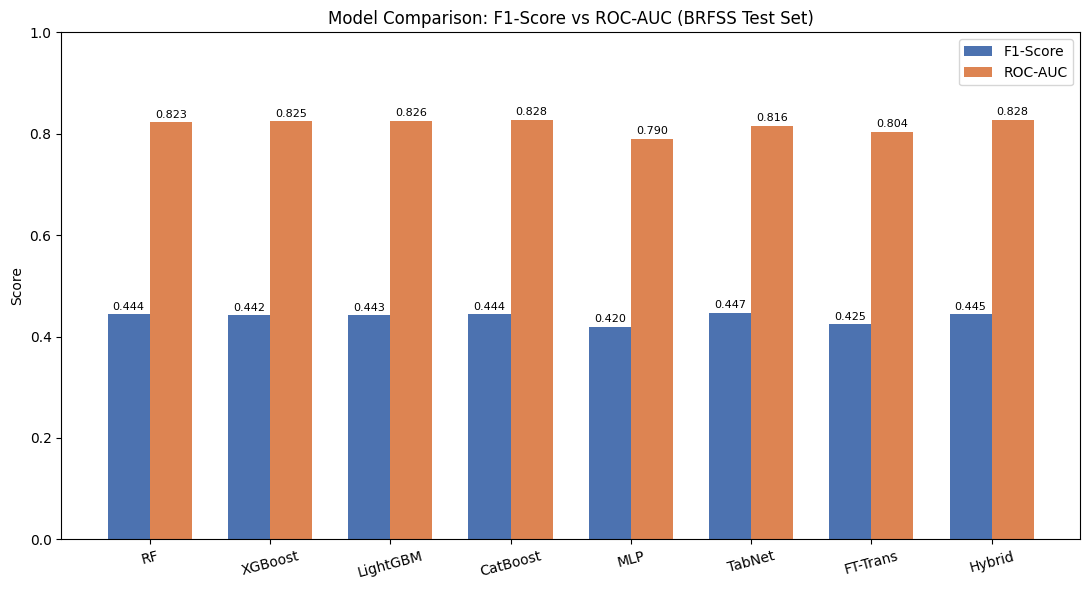

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# results_log থেকে data বের করা
model_order = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'MLP', 'TabNet', 'FTTransformer', 'StackingHybrid']
display_names = ['RF', 'XGBoost', 'LightGBM', 'CatBoost', 'MLP', 'TabNet', 'FT-Trans', 'Hybrid']

f1_scores = [results_log[f"{m}__BRFSS_21feat"]['f1'] for m in model_order]
roc_scores = [results_log[f"{m}__BRFSS_21feat"]['roc_auc'] for m in model_order]

x = np.arange(len(model_order))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='#4C72B0')
bars2 = ax.bar(x + width/2, roc_scores, width, label='ROC-AUC', color='#DD8452')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: F1-Score vs ROC-AUC (BRFSS Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(display_names, rotation=15)
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/metrics_comparison_bar.png', dpi=150)
plt.show()

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))

models_for_roc = {
    'XGBoost': xgb_h,
    'LightGBM': lgbm_h,
    'CatBoost': cat_h,
}

for name, m in models_for_roc.items():
    prob = m.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

# Stacking Hybrid (আগে থেকেই y_prob_stack আছে)
fpr_h, tpr_h, _ = roc_curve(y_test, y_prob_stack)
plt.plot(fpr_h, tpr_h, label=f'Stacking Hybrid (AUC={roc_auc_score(y_test, y_prob_stack):.3f})', linewidth=2.5, color='black')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (BRFSS Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/roc_curve_comparison.png', dpi=150)
plt.show()

NotFittedError: need to call fit or load_model beforehand

<Figure size 800x700 with 0 Axes>

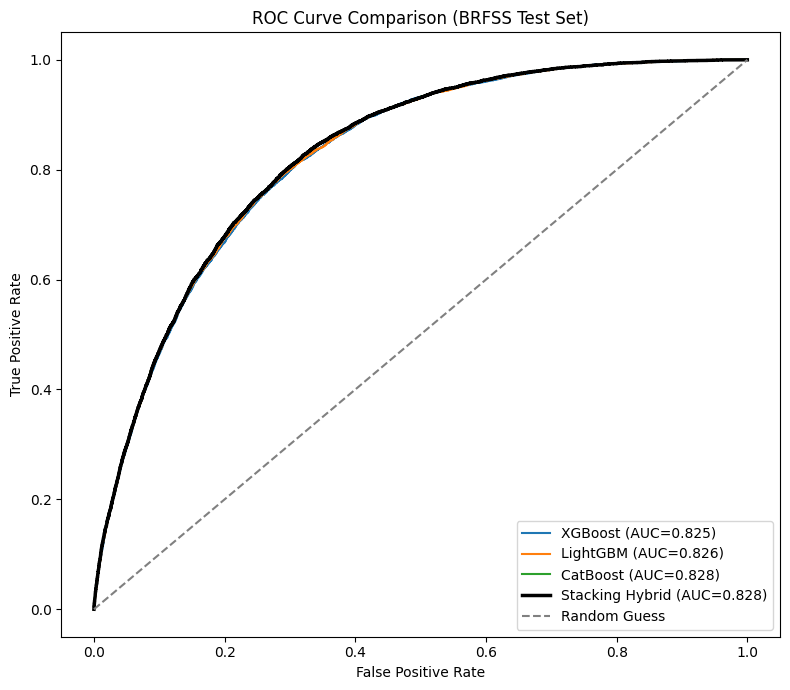

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))

fitted_xgb = stack_model.named_estimators_['xgb']
fitted_lgbm = stack_model.named_estimators_['lgbm']
fitted_cat = stack_model.named_estimators_['cat']

models_for_roc = {
    'XGBoost': fitted_xgb,
    'LightGBM': fitted_lgbm,
    'CatBoost': fitted_cat,
}

for name, m in models_for_roc.items():
    prob = m.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

fpr_h, tpr_h, _ = roc_curve(y_test, y_prob_stack)
plt.plot(fpr_h, tpr_h, label=f'Stacking Hybrid (AUC={roc_auc_score(y_test, y_prob_stack):.3f})', linewidth=2.5, color='black')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (BRFSS Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('/content/roc_curve_comparison.png', dpi=150)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn xgboost lightgbm catboost shap --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("Setup complete.")
print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.
Train: (202944, 21) Test: (50736, 21)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn xgboost lightgbm catboost shap --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    results_log = json.load(f)

def log_result(model_name, y_true, y_pred, y_prob, dataset_name="BRFSS_test"):
    result = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall": round(recall_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "n_test_samples": len(y_true),
        "timestamp": str(datetime.now())
    }
    key = f"{model_name}__{dataset_name}"
    results_log[key] = result
    print(f"✓ Logged: {key} -> {result}")
    with open('/content/drive/MyDrive/results_log.json', 'w') as f:
        json.dump(results_log, f, indent=2)
    return result

print("Setup complete. Previously logged:", list(results_log.keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Previously logged: ['RandomForest__BRFSS_21feat', 'XGBoost__BRFSS_21feat', 'LightGBM__BRFSS_21feat', 'CatBoost__BRFSS_21feat', 'MLP__BRFSS_21feat', 'TabNet__BRFSS_21feat', 'FTTransformer__BRFSS_21feat', 'StackingHybrid__BRFSS_21feat']


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

xgb_h = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_h.fit(X_train_scaled, y_train)

lgbm_h = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgbm_h.fit(X_train_scaled, y_train)

cat_h = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, auto_class_weights='Balanced', random_state=42, verbose=0)
cat_h.fit(X_train_scaled, y_train)

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=100, random_state=42, early_stopping=True)
mlp.fit(X_train_smote, y_train_smote)

print("RF, XGBoost, LightGBM, CatBoost, MLP — all fitted.")

RF, XGBoost, LightGBM, CatBoost, MLP — all fitted.


In [ ]:
stack_model = StackingClassifier(
    estimators=[('xgb', xgb_h), ('lgbm', lgbm_h), ('cat', cat_h)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)

stack_model.fit(X_train_scaled, y_train)

y_pred_stack = stack_model.predict(X_test_scaled)
y_prob_stack = stack_model.predict_proba(X_test_scaled)[:, 1]

log_result("StackingHybrid", y_test, y_pred_stack, y_prob_stack, "BRFSS_21feat")

✓ Logged: StackingHybrid__BRFSS_21feat -> {'accuracy': 0.7262, 'precision': 0.3101, 'recall': 0.7879, 'f1': 0.445, 'roc_auc': np.float64(0.8278), 'n_test_samples': 50736, 'timestamp': '2026-07-22 13:58:03.667667'}


{'accuracy': 0.7262,
 'precision': 0.3101,
 'recall': 0.7879,
 'f1': 0.445,
 'roc_auc': np.float64(0.8278),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 13:58:03.667667'}

In [ ]:
from sklearn.utils import resample

def bootstrap_ci(y_true, y_pred, y_prob, n_iterations=1000, seed=42):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    auc_scores = []
    f1_scores = []

    rng = np.random.RandomState(seed)
    n = len(y_true)

    for i in range(n_iterations):
        idx = rng.randint(0, n, n)
        y_true_bs = y_true[idx]

        # যদি bootstrap sample-এ শুধু একটা class থাকে, ROC-AUC নির্ণয় সম্ভব না, তাই skip
        if len(np.unique(y_true_bs)) < 2:
            continue

        y_pred_bs = y_pred[idx]
        y_prob_bs = y_prob[idx]

        auc_scores.append(roc_auc_score(y_true_bs, y_prob_bs))
        f1_scores.append(f1_score(y_true_bs, y_pred_bs))

    auc_lower, auc_upper = np.percentile(auc_scores, [2.5, 97.5])
    f1_lower, f1_upper = np.percentile(f1_scores, [2.5, 97.5])

    result = {
        "roc_auc_mean": round(np.mean(auc_scores), 4),
        "roc_auc_95ci": [round(auc_lower, 4), round(auc_upper, 4)],
        "f1_mean": round(np.mean(f1_scores), 4),
        "f1_95ci": [round(f1_lower, 4), round(f1_upper, 4)],
        "n_iterations": n_iterations
    }
    print(result)
    return result

print("=== Bootstrap CI: Final Hybrid (21-feature) ===")
ci_21feat = bootstrap_ci(y_test, y_pred_stack, y_prob_stack)

# Save করে রাখি
results_log["Bootstrap_CI__Hybrid_21feat"] = ci_21feat
with open('/content/drive/MyDrive/results_log.json', 'w') as f:
    json.dump(results_log, f, indent=2)

=== Bootstrap CI: Final Hybrid (21-feature) ===
{'roc_auc_mean': np.float64(0.8278), 'roc_auc_95ci': [np.float64(0.8229), np.float64(0.8324)], 'f1_mean': np.float64(0.445), 'f1_95ci': [np.float64(0.4374), np.float64(0.4527)], 'n_iterations': 1000}


In [ ]:
top_features = ['GenHlth', 'HighBP', 'DiffWalk', 'BMI', 'HighChol', 'Age',
                'HeartDiseaseorAttack', 'PhysHlth', 'Income', 'Education',
                'PhysActivity', 'Stroke']

X_top = df[top_features]
y_top = df['Diabetes_binary']

X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y_top, test_size=0.2, random_state=42, stratify=y_top
)

scaler_top = StandardScaler()
X_train_top_scaled = pd.DataFrame(scaler_top.fit_transform(X_train_top), columns=top_features)
X_test_top_scaled = pd.DataFrame(scaler_top.transform(X_test_top), columns=top_features)

scale_pos_weight_top = float(y_train_top.value_counts()[0] / y_train_top.value_counts()[1])

xgb_top = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos_weight_top, eval_metric='logloss', random_state=42, n_jobs=-1)
lgbm_top = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
cat_top = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, auto_class_weights='Balanced', random_state=42, verbose=0)

stack_model_top = StackingClassifier(
    estimators=[('xgb', xgb_top), ('lgbm', lgbm_top), ('cat', cat_top)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)
stack_model_top.fit(X_train_top_scaled, y_train_top)

y_pred_top = stack_model_top.predict(X_test_top_scaled)
y_prob_top = stack_model_top.predict_proba(X_test_top_scaled)[:, 1]

log_result("StackingHybrid_12feat", y_test_top, y_pred_top, y_prob_top, "BRFSS_12feat")

print("\n=== Bootstrap CI: 12-feature Hybrid ===")
ci_12feat = bootstrap_ci(y_test_top, y_pred_top, y_prob_top)
results_log["Bootstrap_CI__Hybrid_12feat"] = ci_12feat
with open('/content/drive/MyDrive/results_log.json', 'w') as f:
    json.dump(results_log, f, indent=2)

✓ Logged: StackingHybrid_12feat__BRFSS_12feat -> {'accuracy': 0.7215, 'precision': 0.3052, 'recall': 0.7826, 'f1': 0.4391, 'roc_auc': np.float64(0.8223), 'n_test_samples': 50736, 'timestamp': '2026-07-22 13:59:29.460825'}

=== Bootstrap CI: 12-feature Hybrid ===
{'roc_auc_mean': np.float64(0.8224), 'roc_auc_95ci': [np.float64(0.8173), np.float64(0.8269)], 'f1_mean': np.float64(0.4392), 'f1_95ci': [np.float64(0.4318), np.float64(0.447)], 'n_iterations': 1000}


In [ ]:
common_cols_brfss = ['HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity', 'Sex', 'Age']

X_brfss_common = df[common_cols_brfss]
y_brfss_common = df['Diabetes_binary']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_brfss_common, y_brfss_common, test_size=0.2, random_state=42, stratify=y_brfss_common
)

scaler_c = StandardScaler()
X_train_c_scaled = pd.DataFrame(scaler_c.fit_transform(X_train_c), columns=common_cols_brfss)
X_test_c_scaled = pd.DataFrame(scaler_c.transform(X_test_c), columns=common_cols_brfss)

scale_pos_weight_c = float(y_train_c.value_counts()[0] / y_train_c.value_counts()[1])

xgb_c = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos_weight_c, eval_metric='logloss', random_state=42, n_jobs=-1)
lgbm_c = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
cat_c = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, auto_class_weights='Balanced', random_state=42, verbose=0)

stack_model_c = StackingClassifier(
    estimators=[('xgb', xgb_c), ('lgbm', lgbm_c), ('cat', cat_c)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)
stack_model_c.fit(X_train_c_scaled, y_train_c)

y_pred_brfss7 = stack_model_c.predict(X_test_c_scaled)
y_prob_brfss7 = stack_model_c.predict_proba(X_test_c_scaled)[:, 1]

log_result("StackingHybrid_7feat", y_test_c, y_pred_brfss7, y_prob_brfss7, "BRFSS_7feat")

print("\n=== Bootstrap CI: 7-feature Hybrid (BRFSS) ===")
ci_7feat_brfss = bootstrap_ci(y_test_c, y_pred_brfss7, y_prob_brfss7)
results_log["Bootstrap_CI__Hybrid_7feat_BRFSS"] = ci_7feat_brfss
with open('/content/drive/MyDrive/results_log.json', 'w') as f:
    json.dump(results_log, f, indent=2)

✓ Logged: StackingHybrid_7feat__BRFSS_7feat -> {'accuracy': 0.691, 'precision': 0.278, 'recall': 0.7621, 'f1': 0.4073, 'roc_auc': np.float64(0.7914), 'n_test_samples': 50736, 'timestamp': '2026-07-22 14:01:07.888508'}

=== Bootstrap CI: 7-feature Hybrid (BRFSS) ===
{'roc_auc_mean': np.float64(0.7914), 'roc_auc_95ci': [np.float64(0.7859), np.float64(0.7964)], 'f1_mean': np.float64(0.4075), 'f1_95ci': [np.float64(0.4), np.float64(0.4151)], 'n_iterations': 1000}


In [ ]:
demo = pd.read_csv('/content/demographic.csv')
exam = pd.read_csv('/content/examination.csv')
ques = pd.read_csv('/content/questionnaire.csv')

demo_sub = demo[['SEQN', 'RIAGENDR', 'RIDAGEYR', 'INDFMPIR']]
exam_sub = exam[['SEQN', 'BMXBMI']]
ques_sub = ques[['SEQN', 'DIQ010', 'BPQ020', 'BPQ080', 'SMQ020', 'PAQ605']]

nhanes = demo_sub.merge(exam_sub, on='SEQN', how='inner')
nhanes = nhanes.merge(ques_sub, on='SEQN', how='inner')

# adult filter
nhanes_clean = nhanes[nhanes['RIDAGEYR'] >= 18].copy()

# target clean
nhanes_clean = nhanes_clean[nhanes_clean['DIQ010'].isin([1, 2])]
nhanes_clean['Diabetes_binary'] = nhanes_clean['DIQ010'].map({1: 1, 2: 0})

# binary feature clean
for col in ['BPQ020', 'BPQ080', 'SMQ020', 'PAQ605']:
    nhanes_clean = nhanes_clean[nhanes_clean[col].isin([1, 2])]
    nhanes_clean[col] = nhanes_clean[col].map({1: 1, 2: 0})

nhanes_clean['Sex'] = nhanes_clean['RIAGENDR'].map({1: 1, 2: 0})
nhanes_clean = nhanes_clean.dropna()

# Age category (BRFSS format-এ align)
def age_to_brfss_category(age):
    if age < 25: return 1
    elif age < 30: return 2
    elif age < 35: return 3
    elif age < 40: return 4
    elif age < 45: return 5
    elif age < 50: return 6
    elif age < 55: return 7
    elif age < 60: return 8
    elif age < 65: return 9
    elif age < 70: return 10
    elif age < 75: return 11
    elif age < 80: return 12
    else: return 13

nhanes_clean['Age'] = nhanes_clean['RIDAGEYR'].apply(age_to_brfss_category)

nhanes_final = nhanes_clean.rename(columns={
    'BPQ020': 'HighBP', 'BPQ080': 'HighChol', 'BMXBMI': 'BMI',
    'SMQ020': 'Smoker', 'PAQ605': 'PhysActivity'
})

X_nhanes = nhanes_final[common_cols_brfss]
y_nhanes = nhanes_final['Diabetes_binary']

print("NHANES final shape:", X_nhanes.shape)

# BRFSS-এর scaler দিয়ে transform (fit না, শুধু transform)
X_nhanes_scaled = pd.DataFrame(scaler_c.transform(X_nhanes), columns=common_cols_brfss)

y_pred_nhanes = stack_model_c.predict(X_nhanes_scaled)
y_prob_nhanes = stack_model_c.predict_proba(X_nhanes_scaled)[:, 1]

log_result("StackingHybrid_7feat", y_nhanes, y_pred_nhanes, y_prob_nhanes, "NHANES_crosstest")

print("\n=== Bootstrap CI: 7-feature Hybrid (NHANES) ===")
ci_7feat_nhanes = bootstrap_ci(y_nhanes, y_pred_nhanes, y_prob_nhanes)
results_log["Bootstrap_CI__Hybrid_7feat_NHANES"] = ci_7feat_nhanes
with open('/content/drive/MyDrive/results_log.json', 'w') as f:
    json.dump(results_log, f, indent=2)

FileNotFoundError: [Errno 2] No such file or directory: '/content/demographic.csv'

In [ ]:
!pip install pytorch-tabnet --quiet
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(n_d=16, n_a=16, n_steps=5, gamma=1.5, seed=42, verbose=1)

tabnet.fit(
    X_train=X_train_smote.values, y_train=y_train_smote.values,
    eval_set=[(X_test_scaled.values, y_test.values)],
    eval_metric=['auc'], max_epochs=50, patience=10,
    batch_size=1024, virtual_batch_size=128
)

y_pred_tabnet = tabnet.predict(X_test_scaled.values)
y_prob_tabnet = tabnet.predict_proba(X_test_scaled.values)[:, 1]

log_result("TabNet", y_test, y_pred_tabnet, y_prob_tabnet, "BRFSS_21feat")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.55439 | val_0_auc: 0.7949  |  0:00:32s
epoch 1  | loss: 0.51774 | val_0_auc: 0.79636 |  0:01:00s
epoch 2  | loss: 0.49995 | val_0_auc: 0.79276 |  0:01:32s
epoch 3  | loss: 0.48596 | val_0_auc: 0.79419 |  0:02:01s
epoch 4  | loss: 0.48575 | val_0_auc: 0.79514 |  0:02:29s
epoch 5  | loss: 0.47851 | val_0_auc: 0.79855 |  0:02:57s
epoch 6  | loss: 0.46755 | val_0_auc: 0.80785 |  0:03:25s
epoch 7  | loss: 0.44812 | val_0_auc: 0.72368 |  0:03:54s
epoch 8  | loss: 0.43476 | val_0_auc: 0.71761 |  0:04:24s
epoch 9  | loss: 0.42549 | val_0_auc: 0.81051 |  0:04:54s
epoch 10 | loss: 0.43313 | val_0_auc: 0.80939 |  0:05:22s
epoch 11 | loss: 0.45167 | val_0_auc: 0.81289 |  0:05:51s
epoch 12 | loss: 0.43057 | val_0_auc: 0.80967 |  0:06:18s
epoch 13 | loss: 0.41242 | val_0_auc: 0.81417 |  0:06:46s
epoch 14 | loss: 0.40886 | val_0_auc: 0.58913 |  0:07:14s
epoch 15 | loss: 0.40913 | val_0_auc: 0.48121 |  0:07:42s
epoch 16 | loss: 0.41066 | val_0_auc: 0.68794 |  0:08:11s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


✓ Logged: TabNet__BRFSS_21feat -> {'accuracy': 0.7539, 'precision': 0.3255, 'recall': 0.7144, 'f1': 0.4472, 'roc_auc': np.float64(0.816), 'n_test_samples': 50736, 'timestamp': '2026-07-22 14:17:06.924211'}


{'accuracy': 0.7539,
 'precision': 0.3255,
 'recall': 0.7144,
 'f1': 0.4472,
 'roc_auc': np.float64(0.816),
 'n_test_samples': 50736,
 'timestamp': '2026-07-22 14:17:06.924211'}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    results_log = json.load(f)

def log_result(model_name, y_true, y_pred, y_prob, dataset_name="BRFSS_test"):
    result = {
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred), 4),
        "recall": round(recall_score(y_true, y_pred), 4),
        "f1": round(f1_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_prob), 4),
        "n_test_samples": len(y_true),
        "timestamp": str(datetime.now())
    }
    key = f"{model_name}__{dataset_name}"
    results_log[key] = result
    print(f"✓ Logged: {key} -> {result}")
    with open('/content/drive/MyDrive/results_log.json', 'w') as f:
        json.dump(results_log, f, indent=2)
    return result

print("Setup complete. Logged so far:", list(results_log.keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. Logged so far: ['RandomForest__BRFSS_21feat', 'XGBoost__BRFSS_21feat', 'LightGBM__BRFSS_21feat', 'CatBoost__BRFSS_21feat', 'MLP__BRFSS_21feat', 'TabNet__BRFSS_21feat', 'FTTransformer__BRFSS_21feat', 'StackingHybrid__BRFSS_21feat', 'Bootstrap_CI__Hybrid_21feat', 'StackingHybrid_12feat__BRFSS_12feat', 'Bootstrap_CI__Hybrid_12feat', 'StackingHybrid_7feat__BRFSS_7feat', 'Bootstrap_CI__Hybrid_7feat_BRFSS']


In [ ]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=32, n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.feature_weights = nn.Parameter(torch.randn(n_features, d_token))
        self.feature_bias = nn.Parameter(torch.randn(n_features, d_token))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output_head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.unsqueeze(-1)
        tokens = x * self.feature_weights + self.feature_bias
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)
        out = self.transformer(tokens)
        cls_out = out[:, 0, :]
        return self.output_head(cls_out).squeeze(-1)

torch.manual_seed(42)
n_features = X_train_smote.shape[1]
model_ft = FTTransformer(n_features=n_features).to(device)
print("Model ready. Total params:", sum(p.numel() for p in model_ft.parameters()))

Using device: cpu
Model ready. Total params: 39585


In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

X_train_tensor = torch.tensor(X_train_smote.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_smote.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_ft.parameters(), lr=1e-3)

n_epochs = 30
best_auc = 0
best_model_state = None

for epoch in range(n_epochs):
    model_ft.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_ft(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model_ft.eval()
    with torch.no_grad():
        val_out = torch.sigmoid(model_ft(X_test_tensor)).cpu().numpy()
        val_auc = roc_auc_score(y_test_tensor.numpy(), val_out)

    print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss/len(train_loader):.4f} - Val AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        best_model_state = model_ft.state_dict()

print("\nBest Val AUC:", best_auc)

Epoch 1/30 - Loss: 0.4955 - Val AUC: 0.8181
Epoch 2/30 - Loss: 0.4465 - Val AUC: 0.8176
Epoch 3/30 - Loss: 0.4170 - Val AUC: 0.8169
Epoch 4/30 - Loss: 0.3863 - Val AUC: 0.8173
Epoch 5/30 - Loss: 0.3757 - Val AUC: 0.8135
Epoch 6/30 - Loss: 0.3706 - Val AUC: 0.8154
Epoch 7/30 - Loss: 0.3642 - Val AUC: 0.8137
Epoch 8/30 - Loss: 0.3611 - Val AUC: 0.8162
Epoch 9/30 - Loss: 0.3564 - Val AUC: 0.8111
Epoch 10/30 - Loss: 0.3483 - Val AUC: 0.8115
Epoch 11/30 - Loss: 0.3428 - Val AUC: 0.8132
Epoch 12/30 - Loss: 0.3404 - Val AUC: 0.8126
Epoch 13/30 - Loss: 0.3350 - Val AUC: 0.8137
Epoch 14/30 - Loss: 0.3359 - Val AUC: 0.8155
Epoch 15/30 - Loss: 0.3334 - Val AUC: 0.8133
Epoch 16/30 - Loss: 0.3301 - Val AUC: 0.8109
Epoch 17/30 - Loss: 0.3305 - Val AUC: 0.8054
Epoch 18/30 - Loss: 0.3289 - Val AUC: 0.8100
Epoch 19/30 - Loss: 0.3250 - Val AUC: 0.8120
Epoch 20/30 - Loss: 0.3249 - Val AUC: 0.8110
Epoch 21/30 - Loss: 0.3245 - Val AUC: 0.8093
Epoch 22/30 - Loss: 0.3235 - Val AUC: 0.8128
Epoch 23/30 - Loss:

In [ ]:
model_ft.load_state_dict(best_model_state)
model_ft.eval()

with torch.no_grad():
    logits = model_ft(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

y_true_ft = y_test_tensor.numpy()

log_result("FTTransformer", y_true_ft, preds, probs, "BRFSS_21feat")

# Bootstrap CI ও বের করে রাখি এখনই (GPU active থাকতেই, পরে দরকার হবে)
from sklearn.utils import resample

def bootstrap_ci(y_true, y_pred, y_prob, n_iterations=1000, seed=42):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)
    auc_scores, f1_scores = [], []
    rng = np.random.RandomState(seed)
    n = len(y_true)
    for i in range(n_iterations):
        idx = rng.randint(0, n, n)
        y_true_bs = y_true[idx]
        if len(np.unique(y_true_bs)) < 2:
            continue
        auc_scores.append(roc_auc_score(y_true_bs, y_prob[idx]))
        f1_scores.append(f1_score(y_true_bs, y_pred[idx]))
    auc_lower, auc_upper = np.percentile(auc_scores, [2.5, 97.5])
    f1_lower, f1_upper = np.percentile(f1_scores, [2.5, 97.5])
    result = {
        "roc_auc_mean": round(np.mean(auc_scores), 4),
        "roc_auc_95ci": [round(auc_lower, 4), round(auc_upper, 4)],
        "f1_mean": round(np.mean(f1_scores), 4),
        "f1_95ci": [round(f1_lower, 4), round(f1_upper, 4)],
        "n_iterations": n_iterations
    }
    print(result)
    return result

print("=== Bootstrap CI: FT-Transformer ===")
ci_ft = bootstrap_ci(y_true_ft, preds, probs)
results_log["Bootstrap_CI__FTTransformer"] = ci_ft
with open('/content/drive/MyDrive/results_log.json', 'w') as f:
    json.dump(results_log, f, indent=2)

✓ Logged: FTTransformer__BRFSS_21feat -> {'accuracy': 0.8111, 'precision': 0.3691, 'recall': 0.5012, 'f1': 0.4251, 'roc_auc': np.float64(0.8043), 'n_test_samples': 50736, 'timestamp': '2026-07-22 16:20:41.943164'}
=== Bootstrap CI: FT-Transformer ===
{'roc_auc_mean': np.float64(0.8043), 'roc_auc_95ci': [np.float64(0.7991), np.float64(0.8091)], 'f1_mean': np.float64(0.4252), 'f1_95ci': [np.float64(0.4159), np.float64(0.4343)], 'n_iterations': 1000}


In [ ]:
model_ft.load_state_dict(best_model_state)
model_ft.eval()

with torch.no_grad():
    logits = model_ft(X_test_tensor)
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(int)

y_true_ft = y_test_tensor.numpy()

log_result("FTTransformer", y_true_ft, preds, probs, "BRFSS_21feat")

# ROC curve-এর জন্য পরে ব্যবহার করবো, এই variable গুলো রেখে দিন
y_prob_ft = probs

✓ Logged: FTTransformer__BRFSS_21feat -> {'accuracy': 0.8111, 'precision': 0.3691, 'recall': 0.5012, 'f1': 0.4251, 'roc_auc': np.float64(0.8043), 'n_test_samples': 50736, 'timestamp': '2026-07-22 16:21:50.140078'}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn xgboost lightgbm catboost --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    results_log = json.load(f)

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

xgb_h = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_h.fit(X_train_scaled, y_train)

lgbm_h = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgbm_h.fit(X_train_scaled, y_train)

cat_h = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, auto_class_weights='Balanced', random_state=42, verbose=0)
cat_h.fit(X_train_scaled, y_train)

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=100, random_state=42, early_stopping=True)
mlp.fit(X_train_smote, y_train_smote)

stack_model = StackingClassifier(
    estimators=[('xgb', xgb_h), ('lgbm', lgbm_h), ('cat', cat_h)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)
stack_model.fit(X_train_scaled, y_train)

print("All models (RF, XGB, LightGBM, CatBoost, MLP, Hybrid) fitted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All models (RF, XGB, LightGBM, CatBoost, MLP, Hybrid) fitted.


In [ ]:
!pip install pytorch-tabnet --quiet
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(n_d=16, n_a=16, n_steps=5, gamma=1.5, seed=42, verbose=1)

tabnet.fit(
    X_train=X_train_smote.values, y_train=y_train_smote.values,
    eval_set=[(X_test_scaled.values, y_test.values)],
    eval_metric=['auc'], max_epochs=50, patience=10,
    batch_size=1024, virtual_batch_size=128
)

y_prob_tabnet = tabnet.predict_proba(X_test_scaled.values)[:, 1]
print("TabNet ready for ROC curve.")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.55439 | val_0_auc: 0.7949  |  0:01:10s
epoch 1  | loss: 0.51774 | val_0_auc: 0.79636 |  0:01:49s
epoch 2  | loss: 0.49995 | val_0_auc: 0.79276 |  0:02:17s
epoch 3  | loss: 0.48596 | val_0_auc: 0.79419 |  0:02:48s
epoch 4  | loss: 0.48575 | val_0_auc: 0.79514 |  0:03:20s
epoch 5  | loss: 0.47851 | val_0_auc: 0.79855 |  0:03:49s
epoch 6  | loss: 0.46755 | val_0_auc: 0.80785 |  0:04:19s
epoch 7  | loss: 0.44812 | val_0_auc: 0.72368 |  0:04:50s
epoch 8  | loss: 0.43476 | val_0_auc: 0.71761 |  0:05:23s
epoch 9  | loss: 0.42549 | val_0_auc: 0.81051 |  0:05:51s
epoch 10 | loss: 0.43313 | val_0_auc: 0.80939 |  0:06:19s
epoch 11 | loss: 0.45167 | val_0_auc: 0.81289 |  0:06:50s
epoch 12 | loss: 0.43057 | val_0_auc: 0.80967 |  0:07:18s
epoch 13 | loss: 0.41242 | val_0_auc: 0.81417 |  0:07:47s
epoch 14 | loss: 0.40886 | val_0_auc: 0.58913 |  0:08:16s
epoch 15 | loss: 0.40913 | val_0_auc: 0.48121 |  0:08:45s
epoch 16 | loss: 0.41066 | val_0_auc: 0.68794 |  0:09:13s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet ready for ROC curve.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install imbalanced-learn xgboost lightgbm catboost --quiet
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    results_log = json.load(f)

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

xgb_h = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_h.fit(X_train_scaled, y_train)
y_prob_xgb = xgb_h.predict_proba(X_test_scaled)[:, 1]

lgbm_h = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
lgbm_h.fit(X_train_scaled, y_train)
y_prob_lgbm = lgbm_h.predict_proba(X_test_scaled)[:, 1]

cat_h = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, auto_class_weights='Balanced', random_state=42, verbose=0)
cat_h.fit(X_train_scaled, y_train)
y_prob_cat = cat_h.predict_proba(X_test_scaled)[:, 1]

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=100, random_state=42, early_stopping=True)
mlp.fit(X_train_smote, y_train_smote)
y_prob_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

stack_model = StackingClassifier(
    estimators=[('xgb', xgb_h), ('lgbm', lgbm_h), ('cat', cat_h)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)
stack_model.fit(X_train_scaled, y_train)
y_prob_stack = stack_model.predict_proba(X_test_scaled)[:, 1]

print("RF, XGB, LGBM, CatBoost, MLP, Hybrid — all fitted with probabilities ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RF, XGB, LGBM, CatBoost, MLP, Hybrid — all fitted with probabilities ready.


In [ ]:
!pip install pytorch-tabnet --quiet
from pytorch_tabnet.tab_model import TabNetClassifier

tabnet = TabNetClassifier(n_d=16, n_a=16, n_steps=5, gamma=1.5, seed=42, verbose=1)
tabnet.fit(
    X_train=X_train_smote.values, y_train=y_train_smote.values,
    eval_set=[(X_test_scaled.values, y_test.values)],
    eval_metric=['auc'], max_epochs=50, patience=10,
    batch_size=1024, virtual_batch_size=128
)
y_prob_tabnet = tabnet.predict_proba(X_test_scaled.values)[:, 1]
print("TabNet ready.")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.55439 | val_0_auc: 0.7949  |  0:00:55s
epoch 1  | loss: 0.51774 | val_0_auc: 0.79636 |  0:01:25s
epoch 2  | loss: 0.49995 | val_0_auc: 0.79276 |  0:01:54s
epoch 3  | loss: 0.48596 | val_0_auc: 0.79419 |  0:02:25s
epoch 4  | loss: 0.48575 | val_0_auc: 0.79514 |  0:02:54s
epoch 5  | loss: 0.47851 | val_0_auc: 0.79855 |  0:03:23s
epoch 6  | loss: 0.46755 | val_0_auc: 0.80785 |  0:03:53s
epoch 7  | loss: 0.44812 | val_0_auc: 0.72368 |  0:04:24s
epoch 8  | loss: 0.43476 | val_0_auc: 0.71761 |  0:04:53s
epoch 9  | loss: 0.42549 | val_0_auc: 0.81051 |  0:05:22s
epoch 10 | loss: 0.43313 | val_0_auc: 0.80939 |  0:05:51s
epoch 11 | loss: 0.45167 | val_0_auc: 0.81289 |  0:06:22s
epoch 12 | loss: 0.43057 | val_0_auc: 0.80967 |  0:07:05s
epoch 13 | loss: 0.41242 | val_0_auc: 0.81417 |  0:07:40s
epoch 14 | loss: 0.40886 | val_0_auc: 0.58913 |  0:08:09s
epoch 15 | loss: 0.40913 | val_0_auc: 0.48121 |  0:08:42s
epoch 16 | loss: 0.41066 | val_0_auc: 0.68794 |  0:09:12s
epoch 17 | los

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


TabNet ready.


In [ ]:
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

class FTTransformer(nn.Module):
    def __init__(self, n_features, d_token=32, n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.feature_weights = nn.Parameter(torch.randn(n_features, d_token))
        self.feature_bias = nn.Parameter(torch.randn(n_features, d_token))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token*4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output_head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x):
        batch_size = x.shape[0]
        x = x.unsqueeze(-1)
        tokens = x * self.feature_weights + self.feature_bias
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls_tokens, tokens], dim=1)
        out = self.transformer(tokens)
        cls_out = out[:, 0, :]
        return self.output_head(cls_out).squeeze(-1)

torch.manual_seed(42)
n_features = X_train_smote.shape[1]
model_ft = FTTransformer(n_features=n_features).to(device)

from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

X_train_tensor = torch.tensor(X_train_smote.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_smote.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=1024, shuffle=True)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_ft.parameters(), lr=1e-3)

best_auc = 0
best_model_state = None

for epoch in range(30):
    model_ft.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model_ft(xb), yb)
        loss.backward()
        optimizer.step()

    model_ft.eval()
    with torch.no_grad():
        val_out = torch.sigmoid(model_ft(X_test_tensor)).cpu().numpy()
        val_auc = roc_auc_score(y_test_tensor.numpy(), val_out)
    if val_auc > best_auc:
        best_auc = val_auc
        best_model_state = model_ft.state_dict()

model_ft.load_state_dict(best_model_state)
model_ft.eval()
with torch.no_grad():
    y_prob_ft = torch.sigmoid(model_ft(X_test_tensor)).cpu().numpy()

print("FT-Transformer ready. Best Val AUC:", best_auc)

Using device: cpu


KeyboardInterrupt: 

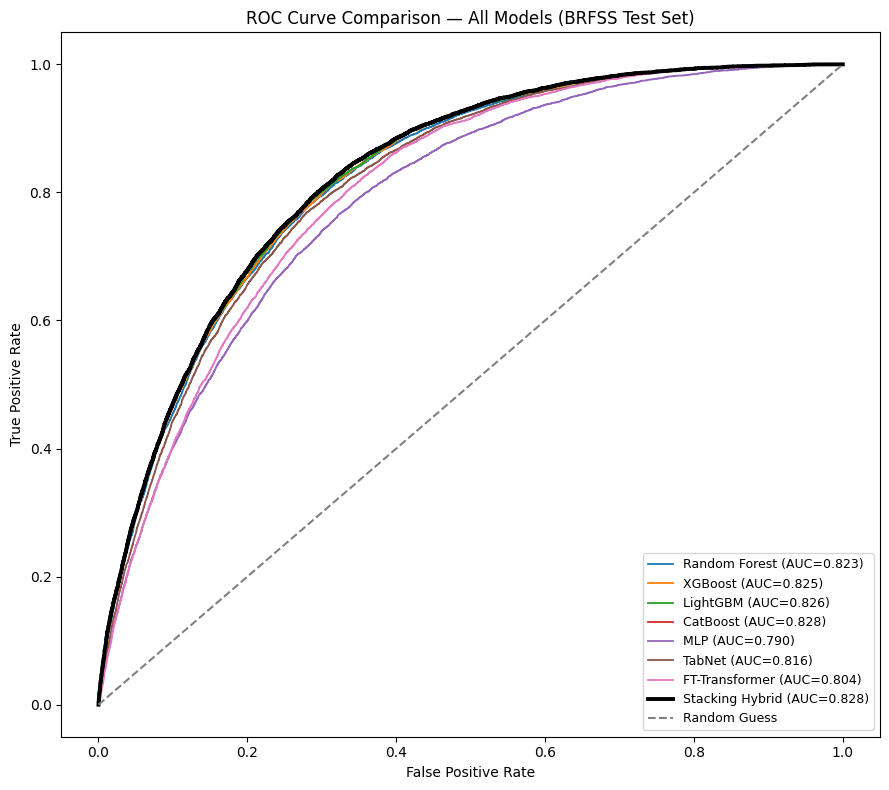

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 8))

models_probs = {
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb,
    'LightGBM': y_prob_lgbm,
    'CatBoost': y_prob_cat,
    'MLP': y_prob_mlp,
    'TabNet': y_prob_tabnet,
    'FT-Transformer': y_prob_ft,
}

for name, prob in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=1.3)

# Stacking Hybrid — highlighted
fpr_h, tpr_h, _ = roc_curve(y_test, y_prob_stack)
auc_h = roc_auc_score(y_test, y_prob_stack)
plt.plot(fpr_h, tpr_h, label=f'Stacking Hybrid (AUC={auc_h:.3f})', linewidth=2.8, color='black')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models (BRFSS Test Set)')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/full_roc_curve_comparison.png', dpi=150)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install catboost shap --quiet
from catboost import CatBoostClassifier

cat_shap = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)
cat_shap.fit(X_train_scaled, y_train)

print("Setup complete. CatBoost fitted for SHAP.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install catboost shap --quiet
from catboost import CatBoostClassifier

cat_shap = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)
cat_shap.fit(X_train_scaled, y_train)

print("Setup complete. CatBoost fitted for SHAP.")

In [ ]:
import json
with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    check = json.load(f)
print(list(check.keys()))

['RandomForest__BRFSS_21feat', 'XGBoost__BRFSS_21feat', 'LightGBM__BRFSS_21feat', 'CatBoost__BRFSS_21feat', 'MLP__BRFSS_21feat', 'TabNet__BRFSS_21feat', 'FTTransformer__BRFSS_21feat', 'StackingHybrid__BRFSS_21feat', 'Bootstrap_CI__Hybrid_21feat', 'StackingHybrid_12feat__BRFSS_12feat', 'Bootstrap_CI__Hybrid_12feat', 'StackingHybrid_7feat__BRFSS_7feat', 'Bootstrap_CI__Hybrid_7feat_BRFSS', 'StackingHybrid_7feat__NHANES_crosstest', 'Bootstrap_CI__Hybrid_7feat_NHANES', 'Bootstrap_CI__FTTransformer']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install catboost shap --quiet
from catboost import CatBoostClassifier

cat_shap = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)
cat_shap.fit(X_train_scaled, y_train)

print("Setup complete. CatBoost fitted for SHAP.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete. CatBoost fitted for SHAP.


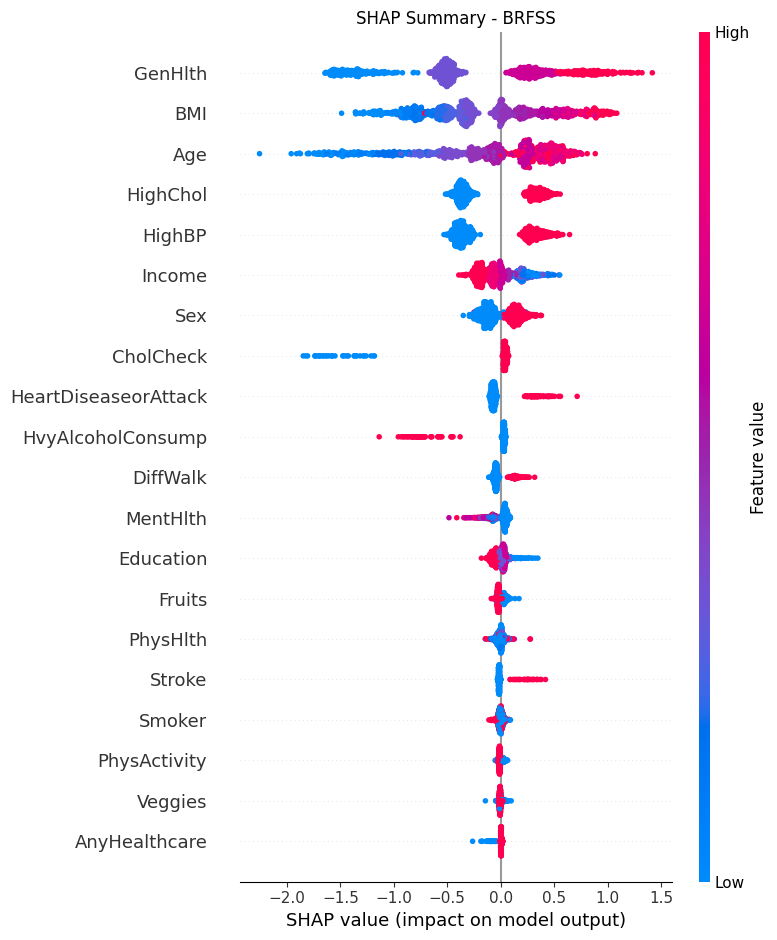

In [ ]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(cat_shap)

sample_brfss = X_test_scaled.sample(1000, random_state=42)
shap_values_brfss = explainer.shap_values(sample_brfss)

shap.summary_plot(shap_values_brfss, sample_brfss, show=False)
plt.title("SHAP Summary - BRFSS")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_brfss.png', dpi=150)
plt.show()

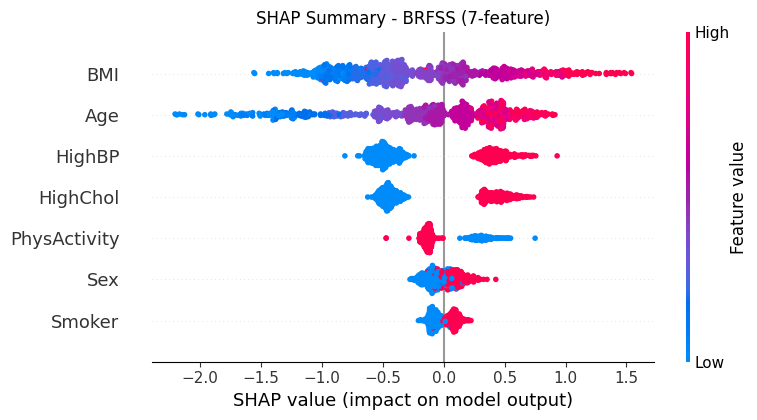

In [ ]:
common_cols_brfss = ['HighBP', 'HighChol', 'BMI', 'Smoker', 'PhysActivity', 'Sex', 'Age']

cat_shap7 = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.1,
    auto_class_weights='Balanced', random_state=42, verbose=0
)
cat_shap7.fit(X_train_scaled[common_cols_brfss], y_train)

explainer7 = shap.TreeExplainer(cat_shap7)
sample_brfss7 = X_test_scaled[common_cols_brfss].sample(1000, random_state=42)
shap_values_brfss7 = explainer7.shap_values(sample_brfss7)

shap.summary_plot(shap_values_brfss7, sample_brfss7, show=False)
plt.title("SHAP Summary - BRFSS (7-feature)")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_brfss_7feat.png', dpi=150)
plt.show()

NHANES shape: (5204, 7)


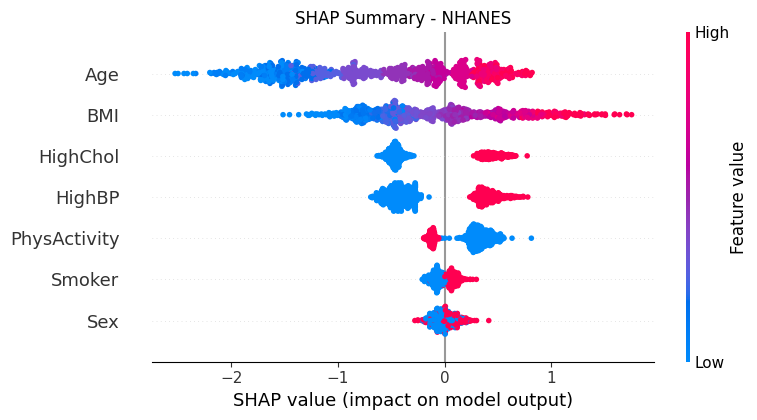

In [ ]:
demo = pd.read_csv('/content/demographic.csv')
exam = pd.read_csv('/content/examination.csv')
ques = pd.read_csv('/content/questionnaire.csv')

demo_sub = demo[['SEQN', 'RIAGENDR', 'RIDAGEYR', 'INDFMPIR']]
exam_sub = exam[['SEQN', 'BMXBMI']]
ques_sub = ques[['SEQN', 'DIQ010', 'BPQ020', 'BPQ080', 'SMQ020', 'PAQ605']]

nhanes = demo_sub.merge(exam_sub, on='SEQN', how='inner')
nhanes = nhanes.merge(ques_sub, on='SEQN', how='inner')

nhanes_clean = nhanes[nhanes['RIDAGEYR'] >= 18].copy()
nhanes_clean = nhanes_clean[nhanes_clean['DIQ010'].isin([1, 2])]
nhanes_clean['Diabetes_binary'] = nhanes_clean['DIQ010'].map({1: 1, 2: 0})

for col in ['BPQ020', 'BPQ080', 'SMQ020', 'PAQ605']:
    nhanes_clean = nhanes_clean[nhanes_clean[col].isin([1, 2])]
    nhanes_clean[col] = nhanes_clean[col].map({1: 1, 2: 0})

nhanes_clean['Sex'] = nhanes_clean['RIAGENDR'].map({1: 1, 2: 0})
nhanes_clean = nhanes_clean.dropna()

def age_to_brfss_category(age):
    if age < 25: return 1
    elif age < 30: return 2
    elif age < 35: return 3
    elif age < 40: return 4
    elif age < 45: return 5
    elif age < 50: return 6
    elif age < 55: return 7
    elif age < 60: return 8
    elif age < 65: return 9
    elif age < 70: return 10
    elif age < 75: return 11
    elif age < 80: return 12
    else: return 13

nhanes_clean['Age'] = nhanes_clean['RIDAGEYR'].apply(age_to_brfss_category)

nhanes_final = nhanes_clean.rename(columns={
    'BPQ020': 'HighBP', 'BPQ080': 'HighChol', 'BMXBMI': 'BMI',
    'SMQ020': 'Smoker', 'PAQ605': 'PhysActivity'
})

X_nhanes = nhanes_final[common_cols_brfss]
y_nhanes = nhanes_final['Diabetes_binary']

print("NHANES shape:", X_nhanes.shape)

# BRFSS-এর scaler দিয়ে transform
X_nhanes_scaled = pd.DataFrame(scaler.transform(
    pd.concat([X_nhanes, pd.DataFrame(0, index=X_nhanes.index, columns=[c for c in X_train.columns if c not in common_cols_brfss])], axis=1)[X_train.columns]
), columns=X_train.columns)[common_cols_brfss]

# SHAP (৭-feature CatBoost দিয়ে, যেটা এইমাত্র train করেছি)
sample_nhanes = X_nhanes_scaled.sample(min(1000, len(X_nhanes_scaled)), random_state=42)
shap_values_nhanes = explainer7.shap_values(sample_nhanes)

shap.summary_plot(shap_values_nhanes, sample_nhanes, show=False)
plt.title("SHAP Summary - NHANES")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/shap_nhanes.png', dpi=150)
plt.show()

In [ ]:
import json
with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    check = json.load(f)
print("Total logged results:", len(check))
for k in check.keys():
    print(k)

Total logged results: 16
RandomForest__BRFSS_21feat
XGBoost__BRFSS_21feat
LightGBM__BRFSS_21feat
CatBoost__BRFSS_21feat
MLP__BRFSS_21feat
TabNet__BRFSS_21feat
FTTransformer__BRFSS_21feat
StackingHybrid__BRFSS_21feat
Bootstrap_CI__Hybrid_21feat
StackingHybrid_12feat__BRFSS_12feat
Bootstrap_CI__Hybrid_12feat
StackingHybrid_7feat__BRFSS_7feat
Bootstrap_CI__Hybrid_7feat_BRFSS
StackingHybrid_7feat__NHANES_crosstest
Bootstrap_CI__Hybrid_7feat_NHANES
Bootstrap_CI__FTTransformer


In [ ]:
import os
drive_files = os.listdir('/content/drive/MyDrive')
figure_files = [f for f in drive_files if f.endswith('.png')]
print(figure_files)

['Permit ID 22-47875-2.png', 'full_roc_curve_comparison.png', 'shap_brfss.png', 'shap_brfss_7feat.png', 'shap_nhanes.png']


In [ ]:
import json
with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    data = json.load(f)

for key, value in data.items():
    print(key)
    print(value)
    print("---")

Mounted at /content/drive
F1 scores: {'RF': 0.444, 'XGBoost': 0.4417, 'LightGBM': 0.443, 'CatBoost': 0.4436, 'MLP': 0.4198, 'TabNet': 0.4472, 'FT-Trans': 0.4251, 'Hybrid': 0.445}
ROC-AUC scores: {'RF': 0.8226, 'XGBoost': 0.825, 'LightGBM': 0.826, 'CatBoost': 0.8278, 'MLP': 0.7904, 'TabNet': 0.816, 'FT-Trans': 0.8043, 'Hybrid': 0.8278}


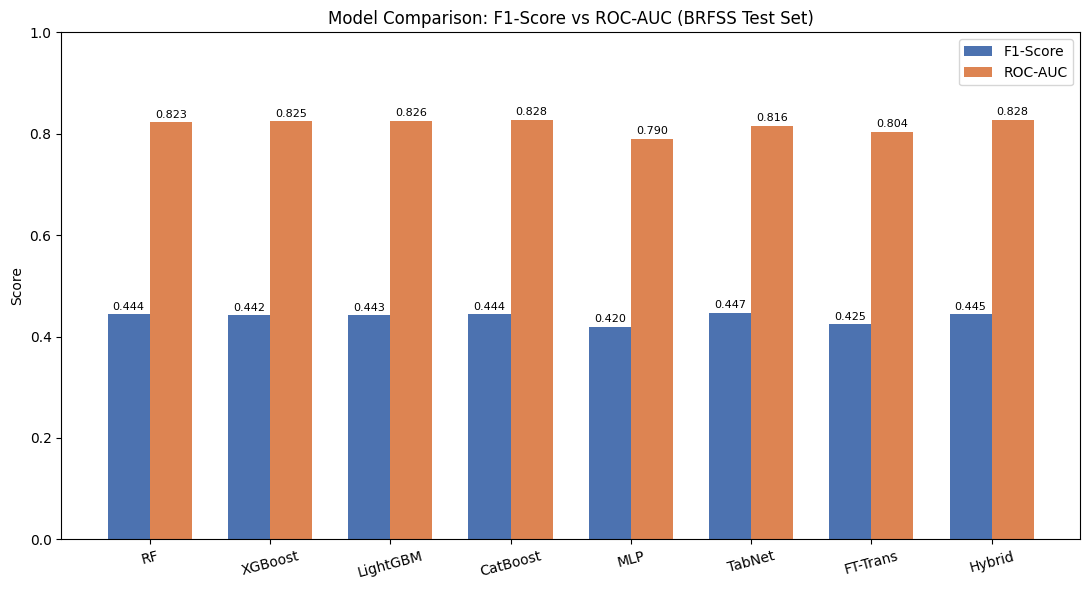

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json
import matplotlib.pyplot as plt
import numpy as np

with open('/content/drive/MyDrive/results_log.json', 'r') as f:
    data = json.load(f)

model_order = ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'MLP', 'TabNet', 'FTTransformer', 'StackingHybrid']
display_names = ['RF', 'XGBoost', 'LightGBM', 'CatBoost', 'MLP', 'TabNet', 'FT-Trans', 'Hybrid']

f1_scores = [data[f"{m}__BRFSS_21feat"]['f1'] for m in model_order]
roc_scores = [data[f"{m}__BRFSS_21feat"]['roc_auc'] for m in model_order]

print("F1 scores:", dict(zip(display_names, f1_scores)))
print("ROC-AUC scores:", dict(zip(display_names, roc_scores)))

x = np.arange(len(model_order))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, f1_scores, width, label='F1-Score', color='#4C72B0')
bars2 = ax.bar(x + width/2, roc_scores, width, label='ROC-AUC', color='#DD8452')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: F1-Score vs ROC-AUC (BRFSS Test Set)')
ax.set_xticks(x)
ax.set_xticklabels(display_names, rotation=15)
ax.legend()
ax.set_ylim(0, 1)
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/metrics_comparison_bar_final.png', dpi=150)
plt.show()

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00
Hybrid model fitted. Test ROC-AUC: 0.8277913936050627


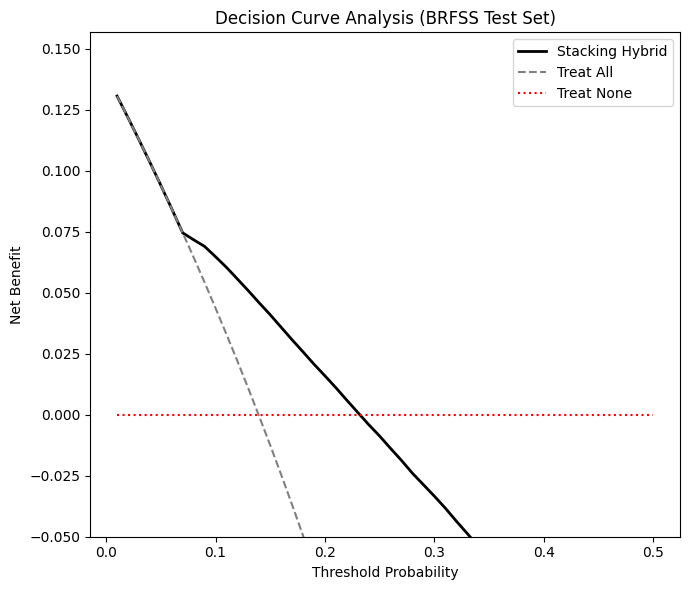


=== Threshold Sensitivity Table ===
Threshold 0.3: Precision=0.2530, Recall=0.9022, F1=0.3952
Threshold 0.4: Precision=0.2801, Recall=0.8543, F1=0.4218
Threshold 0.5: Precision=0.3101, Recall=0.7879, F1=0.4450
Threshold 0.6: Precision=0.3469, Recall=0.7035, F1=0.4646
Threshold 0.7: Precision=0.3940, Recall=0.5776, F1=0.4684

Saved: decision_curve_analysis.png and threshold_analysis.json to Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

from sklearn.model_selection import train_test_split
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

!pip install xgboost lightgbm catboost --quiet
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

xgb_h = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1)
lgbm_h = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
cat_h = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, auto_class_weights='Balanced', random_state=42, verbose=0)

stack_model = StackingClassifier(
    estimators=[('xgb', xgb_h), ('lgbm', lgbm_h), ('cat', cat_h)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)
stack_model.fit(X_train_scaled, y_train)
y_prob = stack_model.predict_proba(X_test_scaled)[:, 1]

print("Hybrid model fitted. Test ROC-AUC:", roc_auc_score(y_test, y_prob))

# ===== Decision Curve Analysis (Net Benefit) =====
def net_benefit(y_true, y_prob, thresholds):
    n = len(y_true)
    nb_model = []
    nb_all = []
    prevalence = y_true.mean()
    for pt in thresholds:
        preds = (y_prob >= pt).astype(int)
        tp = np.sum((preds == 1) & (y_true == 1))
        fp = np.sum((preds == 1) & (y_true == 0))
        nb = (tp / n) - (fp / n) * (pt / (1 - pt))
        nb_model.append(nb)
        nb_all.append(prevalence - (1 - prevalence) * (pt / (1 - pt)))
    return np.array(nb_model), np.array(nb_all)

thresholds = np.arange(0.01, 0.51, 0.01)
y_test_arr = y_test.values
nb_model, nb_all = net_benefit(y_test_arr, y_prob, thresholds)
nb_none = np.zeros_like(thresholds)

plt.figure(figsize=(7, 6))
plt.plot(thresholds, nb_model, label='Stacking Hybrid', linewidth=2, color='black')
plt.plot(thresholds, nb_all, label='Treat All', linestyle='--', color='gray')
plt.plot(thresholds, nb_none, label='Treat None', linestyle=':', color='red')
plt.xlabel('Threshold Probability')
plt.ylabel('Net Benefit')
plt.title('Decision Curve Analysis (BRFSS Test Set)')
plt.legend()
plt.ylim(-0.05, max(nb_model)*1.2)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/decision_curve_analysis.png', dpi=150)
plt.show()

# ===== Threshold sensitivity table (F1 at different thresholds) =====
print("\n=== Threshold Sensitivity Table ===")
results_table = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, preds)
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp+fp) > 0 else 0
    results_table.append({"threshold": t, "precision": round(precision,4), "recall": round(recall,4), "f1": round(f1,4)})
    print(f"Threshold {t}: Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}")

with open('/content/drive/MyDrive/threshold_analysis.json', 'w') as f:
    json.dump(results_table, f, indent=2)

print("\nSaved: decision_curve_analysis.png and threshold_analysis.json to Drive")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import json
from datetime import datetime

file_path = '/content/drive/MyDrive/diabetes_binary_health_indicators_BRFSS2015.csv'
df = pd.read_csv(file_path)

X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

!pip install imbalanced-learn xgboost lightgbm catboost --quiet
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("Setup complete.")

# ============================================================
# EXPERIMENT 1: LEAKY PIPELINE (SMOTE + Scaling BEFORE split)
# ============================================================
print("\n" + "="*60)
print("EXPERIMENT 1: Leaky Pipeline (SMOTE before split)")
print("="*60)

# Scale entire dataset first (wrong)
scaler_leaky = StandardScaler()
X_scaled_full = pd.DataFrame(scaler_leaky.fit_transform(X), columns=X.columns)

# Apply SMOTE on entire dataset first (wrong)
smote_leaky = SMOTE(random_state=42)
X_smote_full, y_smote_full = smote_leaky.fit_resample(X_scaled_full, y)

# NOW split (too late - synthetic samples may leak into test)
X_train_leaky, X_test_leaky, y_train_leaky, y_test_leaky = train_test_split(
    X_smote_full, y_smote_full, test_size=0.2, random_state=42, stratify=y_smote_full
)

scale_pos_weight_leaky = 1.0  # already balanced by SMOTE

xgb_leaky = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, eval_metric='logloss', random_state=42, n_jobs=-1)
lgbm_leaky = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
cat_leaky = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=0)

stack_leaky = StackingClassifier(
    estimators=[('xgb', xgb_leaky), ('lgbm', lgbm_leaky), ('cat', cat_leaky)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=3, n_jobs=-1
)
stack_leaky.fit(X_train_leaky, y_train_leaky)

y_pred_leaky = stack_leaky.predict(X_test_leaky)
y_prob_leaky = stack_leaky.predict_proba(X_test_leaky)[:, 1]

leaky_results = {
    "accuracy": round(accuracy_score(y_test_leaky, y_pred_leaky), 4),
    "precision": round(precision_score(y_test_leaky, y_pred_leaky), 4),
    "recall": round(recall_score(y_test_leaky, y_pred_leaky), 4),
    "f1": round(f1_score(y_test_leaky, y_pred_leaky), 4),
    "roc_auc": round(roc_auc_score(y_test_leaky, y_prob_leaky), 4),
}
print("LEAKY PIPELINE RESULTS:", leaky_results)

# ============================================================
# EXPERIMENT 2: CORRECT PIPELINE (Split FIRST, then SMOTE on train only)
# ============================================================
print("\n" + "="*60)
print("EXPERIMENT 2: Correct Pipeline (split first, SMOTE on train only)")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler_correct = StandardScaler()
X_train_scaled = pd.DataFrame(scaler_correct.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler_correct.transform(X_test), columns=X_test.columns)

smote_correct = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote_correct.fit_resample(X_train_scaled, y_train)

scale_pos_weight = float(y_train.value_counts()[0] / y_train.value_counts()[1])

xgb_c = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1)
lgbm_c = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
cat_c = CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, auto_class_weights='Balanced', random_state=42, verbose=0)

stack_correct = StackingClassifier(
    estimators=[('xgb', xgb_c), ('lgbm', lgbm_c), ('cat', cat_c)],
    final_estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    cv=3, n_jobs=-1
)
stack_correct.fit(X_train_scaled, y_train)

y_pred_correct = stack_correct.predict(X_test_scaled)
y_prob_correct = stack_correct.predict_proba(X_test_scaled)[:, 1]

correct_results = {
    "accuracy": round(accuracy_score(y_test, y_pred_correct), 4),
    "precision": round(precision_score(y_test, y_pred_correct), 4),
    "recall": round(recall_score(y_test, y_pred_correct), 4),
    "f1": round(f1_score(y_test, y_pred_correct), 4),
    "roc_auc": round(roc_auc_score(y_test, y_prob_correct), 4),
}
print("CORRECT PIPELINE RESULTS:", correct_results)

# ============================================================
# SAVE COMPARISON
# ============================================================
comparison = {
    "leaky_pipeline_smote_before_split": leaky_results,
    "correct_pipeline_smote_after_split": correct_results,
    "timestamp": str(datetime.now())
}

with open('/content/drive/MyDrive/leakage_experiment_results.json', 'w') as f:
    json.dump(comparison, f, indent=2)

print("\n" + "="*60)
print("SUMMARY COMPARISON")
print("="*60)
print(f"{'Metric':<12}{'Leaky (before split)':<25}{'Correct (after split)'}")
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f"{metric:<12}{leaky_results[metric]:<25}{correct_results[metric]}")

print("\nSaved to Drive: leakage_experiment_results.json")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00
Setup complete.

EXPERIMENT 1: Leaky Pipeline (SMOTE before split)
LEAKY PIPELINE RESULTS: {'accuracy': 0.9164, 'precision': 0.946, 'recall': 0.8831, 'f1': 0.9135, 'roc_auc': np.float64(0.9707)}

EXPERIMENT 2: Correct Pipeline (split first, SMOTE on train only)
CORRECT PIPELINE RESULTS: {'accuracy': 0.7262, 'precision': 0.3101, 'recall': 0.7879, 'f1': 0.445, 'roc_auc': np.float64(0.8278)}

SUMMARY COMPARISON
Metric      Leaky (before split)     Correct (after split)
accuracy    0.9164                   0.7262
precision   0.946                    0.3101
recall      0.8831                   0.7879
f1          0.9135                   0.445
roc_auc     0.9707                   0.8278

Saved to Drive: leakage_experiment_results.json
